In [1]:
import sys
print("Python version:")
print(sys.version)
print("\nVersion info:")
print(sys.version_info)

Python version:
3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]

Version info:
sys.version_info(major=3, minor=10, micro=18, releaselevel='final', serial=0)


In [2]:
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import os
import multiprocessing

physical_cores = multiprocessing.cpu_count()
logical_cores = os.cpu_count()

print(f"Physical cores: {physical_cores}")
print(f"Logical cores (with hyper-threading): {logical_cores}")

Physical cores: 4
Logical cores (with hyper-threading): 4


In [4]:
pip install mediapipe moviepy==1.0.3 gdown yt-dlp SpeechRecognition seaborn

  Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl (413 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.32.0
    Uninstalling protobuf-6.32.0:
      Successfully uninstalled protobuf-6.32.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.8 which is incompatible.


In [5]:
pip install pandas librosa tensorflow imblearn

  Using cached protobuf-6.32.0-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.32.0-cp310-abi3-win_amd64.whl (435 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 6.32.0 which is incompatible.


In [6]:
from yt_dlp import YoutubeDL
import os
import gdown
import pandas as pd
import time, random
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from moviepy.editor import VideoFileClip
import tempfile
import librosa
import subprocess
import soundfile as sf
import speech_recognition as sr
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import tensorflow as tf
from tqdm import tqdm
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import Sequence
from sklearn.preprocessing import LabelEncoder
from concurrent.futures import ThreadPoolExecutor
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [7]:
# url1 = "https://drive.google.com/uc?id=1ZikFl_hiLYBgxL8-TkE4R2bA7Us7OQT0"
# url2 = "https://drive.google.com/uc?id=12vxL3YIKD-BAqLs3ZGL6fUcmfl_S_GsA"
# url3 = "https://drive.google.com/uc?id=1C7d7NDfGKqqiMOMB8SpXVAybSp2JUq5C"

# gdown.download(url1, "datatrain.csv", quiet=False)
# gdown.download(url2, "datatest.csv", quiet=False)
# gdown.download(url3, "submission.csv", quiet=False)

In [8]:
df_train = pd.read_csv('datatrain.csv')
df_test = pd.read_csv('datatest.csv')
submission = pd.read_csv('submission.csv')

In [9]:
df_train_merged = pd.read_csv('df_train_merged.csv')
df_test_merged = pd.read_csv('df_test_merged.csv')

In [10]:
n_train_unknown = (df_train_merged['path'] == "unknown").sum()
print(f"Jumlah gagal (path = 'unknown'): {n_train_unknown}")

print(df_train_merged[df_train_merged['path'] == "unknown"].head())

Jumlah gagal (path = 'unknown'): 24
      id                                              video   emotion     path
388  389  https://drive.google.com/file/d/1-n-P6UQqIBYoT...  Surprise  unknown
500  501  https://www.instagram.com/reel/DMAEL2oS-kx/?ut...       Joy  unknown
682  683  https://scontent-cgk2-1.cdninstagram.com/o1/v/...   Sadness  unknown
683  684  https://scontent-cgk2-2.cdninstagram.com/o1/v/...  Surprise  unknown
684  685  https://scontent-cgk2-2.cdninstagram.com/o1/v/...     Proud  unknown


In [11]:
n_test_unknown = (df_test_merged['path'] == "unknown").sum()
print(f"Jumlah gagal (path = 'unknown'): {n_test_unknown}")

print(df_test_merged[df_test_merged['path'] == "unknown"].head())

Jumlah gagal (path = 'unknown'): 1
      id                                              video     path
106  107  https://drive.google.com/drive/u/7/folders/1gt...  unknown


In [12]:
emotion_correction = {
    "Terkjut": "Surprise",
    "Terkejut": "Surprise",
    "Trkejut": "Surprise",
    "terkejut": "Surprise",
    "Trekejut": "Surprise",
    "kaget": "Surprise",
    "Kaget": "Surprise",
    "Bangga": "Proud",
    "Marah": "Anger",
    "Marh": "Anger",
    "Love": "Joy",
    "Loyalty": "Trust",
    "Faith": "Trust",
    "Percaya": "Trust",
    "Sad": "Sadness",
}

df_train_merged['emotion_fixed'] = df_train_merged['emotion'].replace(emotion_correction)

In [13]:
df_train_merged['emotion_fixed'].value_counts()

emotion_fixed
Surprise    331
Trust       184
Proud       156
Joy          54
Anger        36
Sadness      18
Fear         16
Neutral       8
Name: count, dtype: int64

In [14]:
emotion_label = {
    "Proud": 0,
    "Trust": 1,
    "Joy": 2,
    "Surprise": 3,
    "Neutral": 4,
    "Sadness": 5,
    "Fear": 6,
    "Anger": 7,
}

df_train_merged['emotion_fixed_label'] = df_train_merged['emotion_fixed'].map(emotion_label)

In [15]:
df_train_merged.emotion_fixed_label.value_counts()

emotion_fixed_label
3    331
1    184
0    156
2     54
7     36
5     18
6     16
4      8
Name: count, dtype: int64

In [16]:
df_train_merged = df_train_merged.replace(['unknown', 'Unknown'], np.nan)

df_train_merged = df_train_merged.dropna()

In [17]:
df_train_merged.emotion_fixed_label.value_counts()

emotion_fixed_label
3    321
1    178
0    153
2     51
7     36
5     17
6     16
4      7
Name: count, dtype: int64

In [18]:
df_train_merged.shape

(779, 6)

In [19]:
mp_face = mp.solutions.face_mesh

def crop_select_expression_frame(video_path, frame_skip=5, preview_count=3, max_frames=30, show_scores=False):
    """
    Crop wajah dan pilih frame ekspresi paling jelas, dibatasi max 100 frame
    """
    cap = cv2.VideoCapture(video_path)
    count = 0
    selected_frames = []
    scores_frames = []

    max_score = -1

    with mp_face.FaceMesh(static_image_mode=False, max_num_faces=1) as face_mesh:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            count += 1
            if count % frame_skip != 0:
                continue

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(rgb_frame)

            if not results.multi_face_landmarks:
                continue

            landmarks = results.multi_face_landmarks[0].landmark
            h, w, _ = frame.shape

            # Skor ekspresi
            eye_open_ratio = abs(landmarks[159].y - landmarks[145].y) + abs(landmarks[386].y - landmarks[374].y)
            brow_raise_ratio = abs(landmarks[10].y - landmarks[151].y)
            mouth_open_ratio = abs(landmarks[13].y - landmarks[14].y)
            cheek_ratio = abs(landmarks[78].y - landmarks[308].y)
            score = eye_open_ratio*1.2 + brow_raise_ratio*1.0 + mouth_open_ratio*1.5 + cheek_ratio*0.8
            scores_frames.append((count, score))

            if score > max_score:
                max_score = score
                x_coords = [int(lm.x * w) for lm in landmarks]
                y_coords = [int(lm.y * h) for lm in landmarks]
                x_min, x_max = max(min(x_coords)-30, 0), min(max(x_coords)+30, w)
                y_min, y_max = max(min(y_coords)-30, 0), min(max(y_coords)+30, h)
                crop = frame[y_min:y_max, x_min:x_max]

                # Tambahkan hanya jika belum mencapai max_frames
                if len(selected_frames) < max_frames:
                    selected_frames.append(crop)

    cap.release()

    if show_scores:
        print("Top frame score:", max_score)
        for f, s in scores_frames[:10]:
            print(f"Frame {f}: Score {s:.4f}")

    return selected_frames[:preview_count]  # preview terbatas seperti sebelumnya


In [20]:
def augment_frame_moderate(frame,
                           rotation_range=10,
                           brightness_range=(0.5, 1.7),
                           width_shift_range=0.2,
                           height_shift_range=0.2):
    """Augmentasi moderat: rotasi kecil, brightness, dan translasi"""
    h, w, _ = frame.shape
    augmented = frame.copy()

    # Rotasi ±rotation_range derajat
    angle = random.uniform(-rotation_range, rotation_range)
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    augmented = cv2.warpAffine(augmented, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Brightness / contrast
    alpha = random.uniform(*brightness_range)
    beta = 0  # beta bisa 0 agar tidak terlalu ekstrem
    augmented = cv2.convertScaleAbs(augmented, alpha=alpha, beta=beta)

    # Width & Height shift ±range
    tx = int(random.uniform(-width_shift_range, width_shift_range) * w)
    ty = int(random.uniform(-height_shift_range, height_shift_range) * h)
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    augmented = cv2.warpAffine(augmented, M_trans, (w, h), borderMode=cv2.BORDER_REFLECT)

    return augmented

def crop_center(frame, crop_size=None):
    """Crop center square dari frame"""
    h, w, _ = frame.shape
    if crop_size is None:
        crop_size = min(h, w)
    y1 = h//2 - crop_size//2
    x1 = w//2 - crop_size//2
    return frame[y1:y1+crop_size, x1:x1+crop_size]

def augment_frame_moderate(frame,
                           rotation_range=10,
                           brightness_range=(0.5, 1.7),
                           width_shift_range=0.2,
                           height_shift_range=0.2):
    h, w, _ = frame.shape
    augmented = frame.copy()

    # Rotasi ±rotation_range derajat
    angle = random.uniform(-rotation_range, rotation_range)
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    augmented = cv2.warpAffine(augmented, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Brightness / contrast
    alpha = random.uniform(*brightness_range)
    augmented = cv2.convertScaleAbs(augmented, alpha=alpha, beta=0)

    # Width & Height shift ±range
    tx = int(random.uniform(-width_shift_range, width_shift_range) * w)
    ty = int(random.uniform(-height_shift_range, height_shift_range) * h)
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    augmented = cv2.warpAffine(augmented, M_trans, (w, h), borderMode=cv2.BORDER_REFLECT)

    return augmented

def crop_center(frame, crop_size=None):
    h, w, _ = frame.shape
    if crop_size is None:
        crop_size = min(h, w)
    crop_size = min(crop_size, h, w)  # memastikan crop_size tidak melebihi dimensi gambar
    y1 = max(0, h//2 - crop_size//2)
    x1 = max(0, w//2 - crop_size//2)
    return frame[y1:y1+crop_size, x1:x1+crop_size]

def process_video_face_multi_zoom(video_path, frame_skip=5, preview_count=3, augment_count=3,
                                  zoom_attempts=3, random_crop_count=2):
    """
    Crop wajah ekspresi terbaik jika terdeteksi
    Zoom multi-level jika gagal
    Fallback crop center / random frame
    """
    frames = crop_select_expression_frame(video_path, frame_skip=frame_skip, preview_count=preview_count)
    has_face = len(frames) > 0
    selected_frames = []

    if not has_face:
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        for i in range(total_frames):
            ret, frame = cap.read()
            if not ret or i % frame_skip != 0:
                continue

            detected = False
            for z in range(zoom_attempts):
                crop_size = int(min(frame.shape[:2]) * (0.8 + 0.1*z))
                zoom_crop = crop_center(frame, crop_size)

                # gunakan temporary file unik untuk deteksi wajah
                with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
                    temp_path = tmp.name
                    cv2.imwrite(temp_path, zoom_crop)
                    temp_frames = crop_select_expression_frame(temp_path, frame_skip=1, preview_count=1)
                os.remove(temp_path)

                if temp_frames:
                    selected_frames.append(temp_frames[0])
                    detected = True
                    has_face = True
                    break
            if detected:
                break

        cap.release()

        if not has_face:
            # fallback crop center / random
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            random_idx = random.sample(range(total_frames), min(random_crop_count, total_frames))
            for i in range(total_frames):
                ret, frame = cap.read()
                if not ret or i not in random_idx:
                    continue
                selected_frames.append(crop_center(frame))
            cap.release()

        frames = selected_frames[:preview_count]

    # Augmentasi
    augmented_frames = []
    for f in frames:
        augmented_frames.append(f)
        for _ in range(augment_count):
            augmented_frames.append(augment_frame_moderate(f))

    return augmented_frames, has_face


In [21]:
def load_audio(video_path, sample_rate=8000, max_duration=60):
    """
    Ekstrak audio dari video ke memori dan normalisasi.
    Returns:
        y: np.array, audio sequence
        sample_rate: int
    """
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=True) as tmp:
        clip = VideoFileClip(video_path)
        clip.audio.write_audiofile(tmp.name, fps=sample_rate, nbytes=2, verbose=False, logger=None)
        clip.close()
        y, _ = librosa.load(tmp.name, sr=sample_rate, mono=True, duration=max_duration)
    y = y / (np.max(np.abs(y)) + 1e-6)
    # Jika durasi kurang dari max_duration, pad dengan 0
    target_len = sample_rate * max_duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32), sample_rate

In [22]:
def extract_audio_tensor(y, sr,
                         n_mfcc=20,
                         n_chroma=12,
                         n_fft=2048,
                         hop_length=512,
                         max_len=300):
    """
    Ekstrak sequence audio features (MFCC, Chroma, Spectrogram, RMS, Pitch, Tempo)
    gabung jadi tensor (time, features)
    """
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                n_fft=n_fft, hop_length=hop_length).T

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr,
                                         n_fft=n_fft, hop_length=hop_length).T

    # Spectrogram (mel power)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr,
                                              n_fft=n_fft, hop_length=hop_length).T
    mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    # RMS
    rms = librosa.feature.rms(y=y, frame_length=n_fft,
                              hop_length=hop_length).T

    # Pitch (f0)
    f0, _, _ = librosa.pyin(y,
                            fmin=librosa.note_to_hz('C2'),
                            fmax=librosa.note_to_hz('C7'),
                            frame_length=n_fft,
                            hop_length=hop_length)
    f0 = np.nan_to_num(f0).reshape(-1, 1)

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo_vec = np.full((mfcc.shape[0], 1), tempo)

    # Sinkronisasi panjang
    min_len = min(mfcc.shape[0], chroma.shape[0], mel_spec.shape[0],
                  rms.shape[0], f0.shape[0], tempo_vec.shape[0])

    mfcc, chroma, mel_spec, rms, f0, tempo_vec = (
        mfcc[:min_len], chroma[:min_len], mel_spec[:min_len],
        rms[:min_len], f0[:min_len], tempo_vec[:min_len]
    )

    # Gabungkan semua fitur
    features = np.concatenate([mfcc, chroma, mel_spec, rms, f0, tempo_vec], axis=1)

    # Normalisasi per fitur
    features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-6)

    # Padding/truncate
    if features.shape[0] < max_len:
        pad_len = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_len), (0, 0)), mode="constant")
    else:
        features = features[:max_len, :]

    return features.astype(np.float32)


# Augmentasi audio
def augment_audio(y, sr):
    """
    Augmentasi audio dalam waveform
    """
    # Pitch shift ±2 semitone
    if np.random.rand() < 0.5:
        steps = np.random.uniform(-2, 2)
        y = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=steps)

    # Time stretch 0.9–1.1
    if np.random.rand() < 0.5:
        rate = np.random.uniform(0.9, 1.1)
        y = librosa.effects.time_stretch(y=y, rate=rate)

    # Noise injection
    if np.random.rand() < 0.5:
        noise_amp = 0.005 * np.random.uniform() * np.amax(y)
        y = y + noise_amp * np.random.normal(size=y.shape[0])

    # Gain shift
    if np.random.rand() < 0.5:
        gain = np.random.uniform(0.8, 1.2)
        y = y * gain

    return y

def extract_audio_tensor_with_aug(y, sr, max_len=300, n_mfcc=20):
    """
    Augmentasi dan ekstraksi fitur audio jadi tensor
    """
    # Augmentasi waveform
    y_aug = augment_audio(y, sr)

    # Ekstraksi fitur jadi tensor
    tensor = extract_audio_tensor(y_aug, sr,
                                  n_mfcc=n_mfcc,
                                  max_len=max_len)
    return tensor


In [23]:
import speech_recognition as sr
from moviepy.editor import VideoFileClip
import tempfile
import librosa
import soundfile as sf
import re

def extract_text_from_video(video_path, language='id-ID', max_duration=60, max_segments=5):
    """
    Extract text dari video menggunakan Google Speech-to-Text
    Audio dipotong jadi beberapa segmen (max_segments × max_duration detik)
    """
    texts = []

    # Ekstrak audio ke file sementara
    clip = VideoFileClip(video_path)
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp_path = tmp.name
        clip.audio.write_audiofile(tmp_path, fps=16000, nbytes=2, verbose=False, logger=None)
    clip.close()

    # Load audio full
    y, sr_audio = librosa.load(tmp_path, sr=16000, mono=True)
    total_duration = len(y) / sr_audio

    # Bagi ke segmen
    for i in range(max_segments):
        start = i * max_duration * sr_audio
        end = (i + 1) * max_duration * sr_audio
        if start >= len(y):  # kalau audio sudah habis
            break

        segment = y[int(start):int(min(end, len(y)))]
        seg_path = tmp_path.replace(".wav", f"_{i}.wav")
        sf.write(seg_path, segment, sr_audio)

        # Speech-to-text
        r = sr.Recognizer()
        with sr.AudioFile(seg_path) as source:
            audio_data = r.record(source)
            try:
                text = r.recognize_google(audio_data, language=language)
            except sr.UnknownValueError:
                text = ""
            except sr.RequestError as e:
                print(f"Google API failed: {e}")
                text = ""

        texts.append(text)
        os.remove(seg_path)  # hapus segmen sementara

    # Hapus file audio asli
    os.remove(tmp_path)

    # Gabungkan semua teks
    return " ".join(texts).strip()

def preprocess_text(text):
    """
    Lowercase
    Ganti tanda hubung dengan spasi
    Hapus karakter non-alphanumeric (selain spasi)
    Tanpa stopword removal
    Tanpa stemming
    """
    text = text.lower()

    # ganti tanda hubung dengan spasi
    text = text.replace("-", " ")

    # hapus karakter selain huruf/angka/spasi
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [24]:
# import os
# from tqdm import tqdm

# # Tambahkan kolom transcript kosong dulu
# df_train_merged['transcript'] = ""

# for idx, video_path in tqdm(df_train_merged['path'].items(), total=len(df_train_merged)):
#     if os.path.exists(video_path):
#         try:
#             text = extract_text_from_video(video_path, language='id-ID', max_duration=60)
#             text = preprocess_text(text)
#             df_train_merged.at[idx, 'transcript'] = text
#         except Exception as e:
#             print(f"[ERROR] Video {video_path} gagal diproses: {e}")
#             df_train_merged.at[idx, 'transcript'] = ""
#     else:
#         print(f"[WARNING] File tidak ditemukan: {video_path}")
#         df_train_merged.at[idx, 'transcript'] = ""

In [25]:
df_train_merged = pd.read_csv('df_train_merged_with_text.csv')

In [26]:
df_train_merged.transcript[2]

'saya di rumah gua tuh agak aneh ya biasanya pohon pepaya itu kan lurus ke atas nggak bercabang tapi kita lihat di sini ini pepayanya cabang 3 tuh lihat 123 terus ada batang lagi yang bulat di sini agak aneh tuh ini dia kayak bulat gitu bercabang lagi ya di sini ada percabangan lagi ya bahkan di sebelah sana tuh ada percabangan dia banyak tuh 12345 dan tiap cabangnya itu ada daunnya sama ada pepayanya tuh banyak banget pepaya aja sampai ke atas banyak banget gua seumur hidup baru pertama kali ketemu pepaya yang kayak gini dan uniknya ada di rumah sendiri kenapa bisa kayak gitu ya gue juga nggak ngerti enak buahnya'

In [27]:
emotion_lexicon = {
    'Proud': [
        'bangga', 'berbangga', 'membanggakan', 'kebanggaan', 'self-esteem',
        'harga diri', 'martabat', 'kehormatan', 'prestige', 'prestis',
        'dignitas', 'bermartabat', 'terhormat', 'mulia', 'agung',
        'puas', 'kepuasan', 'satisfied', 'accomplished', 'berprestasi',
        'sukses', 'berhasil', 'triumph', 'kemenangan', 'juara',
        'unggul', 'superior', 'terdepan', 'terbaik', 'excellent',
        'achievement', 'pencapaian', 'prestasi', 'accomplishment', 'fulfill',
        'terpenuhi', 'complete', 'sempurna', 'perfect', 'ideal',
        'optimal', 'maksimal', 'peak', 'puncak', 'top',
        'confident', 'yakin', 'pasti', 'mantap', 'kokoh',
        'kuat', 'solid', 'teguh', 'firm', 'determined',
        'tekad', 'bulat', 'resolve', 'decisive', 'tegas',
        'mobil', 'car', 'ferrari', 'lamborghini', 'mercedes', 'bmw', 'porsche',
        'rumah', 'house', 'mansion', 'villa', 'apartemen', 'penthouse',
        'gelar', 'degree', 'diploma', 'sertifikat', 'certificate', 'award', 'piala',
        'trophy', 'medali', 'medal', 'badge', 'pin', 'ribbon',
        'iphone', 'samsung', 'rolex', 'omega', 'cartier', 'louis vuitton',
        'gucci', 'prada', 'chanel', 'hermes', 'ferrari', 'yacht',
        'private jet', 'jet pribadi', 'kapal', 'pesawat', 'helicopter',
        'bisnis', 'business', 'perusahaan', 'company', 'startup',
        'kantor', 'office', 'gedung', 'building', 'tower',
        'universitas', 'university', 'harvard', 'mit', 'stanford',
        'juara', 'champion', 'winner', 'pemenang', 'first place',
        'keren', 'mantul', 'mantap jiwa', 'gokil', 'goks', 'anjay',
        'wiih', 'kece', 'top banget', 'the best', 'juara dunia',
        'legend', 'epic', 'lit', 'fire', 'savage', 'beast mode',
        'dari', 'memang', 'itu', 'kan', 'dong', 'sih', 'loh',
        'kok', 'gimana', 'kayak gini', 'seperti ini', 'begini',
        'makanya', 'soalnya', 'karena', 'sebab', 'jadi',
        'brand', 'premium', 'exclusive', 'limited edition', 'pro',
        'advance', 'upgrade', 'level up', 'next level', 'high-end',
        'flagship', 'signature', 'masterpiece', 'quality', 'performance'
    ],

    'Trust': [
        'percaya', 'percaya diri', 'aman', 'loyal', 'percaya pada', 'baik',
        'trust', 'believe', 'faith', 'keyakinan', 'yakin', 'convinced',
        'confident', 'assure', 'jamin', 'guarantee', 'pasti', 'certain',
        'sure', 'positive', 'optimis', 'harapan', 'hope', 'expect',
        'secure', 'safety', 'keamanan', 'selamat', 'protected', 'terlindungi',
        'shelter', 'berlindung', 'refuge', 'tempat berlindung', 'comfortable',
        'nyaman', 'tenang', 'damai', 'peace', 'calm', 'santai',
        'rileks', 'relax', 'ease', 'mudah', 'lancar', 'smooth',
        'loyal', 'setia', 'faithful', 'devotion', 'dedikasi', 'committed',
        'komitmen', 'dedication', 'support', 'dukung', 'dukungan', 'backing',
        'solidarity', 'solidaritas', 'unity', 'kesatuan', 'together',
        'bersama', 'team', 'partnership', 'kerjasama', 'cooperation',
        'reliable', 'andal', 'dependable', 'konsisten', 'consistent', 'stable',
        'stabil', 'steady', 'tetap', 'constant', 'unchanged', 'solid',
        'kokoh', 'kuat', 'strong', 'robust', 'durable', 'tahan lama',
        'honest', 'jujur', 'sincere', 'tulus', 'genuine', 'authentic',
        'asli', 'original', 'real', 'nyata', 'true', 'benar',
        'keluarga', 'family', 'orang tua', 'parents', 'ibu', 'ayah', 'mama', 'papa',
        'suami', 'istri', 'husband', 'wife', 'pacar', 'boyfriend', 'girlfriend',
        'sahabat', 'best friend', 'teman', 'friend', 'partner', 'colleague',
        'dokter', 'doctor', 'guru', 'teacher', 'dosen', 'professor',
        'bank', 'insurance', 'asuransi', 'rumah sakit', 'hospital',
        'polisi', 'police', 'pemerintah', 'government', 'negara', 'country',
        'toyota', 'honda', 'suzuki', 'google', 'apple', 'microsoft',
        'brand terkenal', 'merek terpercaya', 'sertifikat', 'lisensi',
        'jaminan', 'warranty', 'garansi', 'customer service',
        'support', 'help desk', 'technical support',
        'oke', 'ok', 'siap', 'gas', 'yoi', 'bet', 'deal', 'fix',
        'trust me bro', 'gue percaya', 'gw yakin', 'pasti bisa',
        'no worry', 'santuy', 'tenang bro', 'chill', 'slow',
        'kan', 'dong', 'sih', 'loh', 'kok', 'emang', 'memang',
        'ya', 'iya', 'betul', 'bener', 'dari', 'pada', 'sama',
        'dengan', 'untuk', 'ke', 'di', 'apa', 'kenapa', 'gimana',
        'verified', 'certified', 'official', 'authorized', 'licensed',
        'security', 'encryption', 'protected', 'backup', 'support',
        'warranty', 'guarantee', 'standard', 'ISO', 'quality assured'
    ],

    'Joy': [
        'senang', 'bahagia', 'gembira', 'ceria', 'senyum', 'happy', 'joy',
        'cheerful', 'merry', 'glad', 'pleased', 'delighted', 'excited',
        'thrilled', 'ecstatic', 'euphoric', 'blissful', 'elated', 'jubilant',
        'tawa', 'laugh', 'laughter', 'giggle', 'chuckle', 'smile', 'grin',
        'beam', 'radiant', 'bersinar', 'cerah', 'bright', 'sparkling',
        'berkilau', 'glowing', 'bercahaya', 'shining', 'brilliant', 'vivid',
        'antusias', 'enthusiastic', 'eager', 'semangat', 'energetic', 'energi',
        'passionate', 'gairah', 'fervent', 'zealous', 'dynamic', 'dinamis',
        'vibrant', 'hidup', 'alive', 'lively', 'animated', 'spirited',
        'puas', 'satisfied', 'content', 'fulfilled', 'gratified', 'enjoy',
        'menikmati', 'pleasure', 'kesenangan', 'fun', 'entertaining',
        'menghibur', 'amusing', 'delightful', 'wonderful', 'fantastic',
        'amazing', 'incredible', 'awesome', 'great', 'excellent',
        'optimis', 'optimistic', 'positive', 'hopeful', 'harapan', 'bright',
        'promising', 'menjanjikan', 'encouraging', 'uplifting', 'inspiring',
        'motivating', 'motivasi', 'boost', 'energizing', 'refreshing',
        'liburan', 'vacation', 'holiday', 'weekend', 'akhir pekan',
        'pesta', 'party', 'celebration', 'perayaan', 'festival',
        'ulang tahun', 'birthday', 'anniversary', 'graduation', 'wisuda',
        'pernikahan', 'wedding', 'honeymoon', 'bulan madu',
        'hadiah', 'gift', 'present', 'surprise', 'kejutan',
        'makanan', 'food', 'pizza', 'ice cream', 'es krim', 'coklat', 'chocolate',
        'kue', 'cake', 'dessert', 'candy', 'permen', 'snack',
        'musik', 'music', 'lagu', 'song', 'konser', 'concert',
        'film', 'movie', 'cinema', 'bioskop', 'game', 'permainan',
        'playground', 'taman bermain', 'pantai', 'beach', 'travel',
        'wisata', 'adventure', 'petualangan', 'sport', 'olahraga',
        'menang', 'victory', 'lottery', 'lotere', 'jackpot',
        'promosi', 'promotion', 'bonus', 'raise', 'kenaikan', 'gaji', 'gajian',
        'wow', 'wih', 'wiih', 'jir', 'anjay', 'mantul', 'keren abis',
        'goks', 'gokil', 'lit', 'fire', 'dope', 'sick', 'rad',
        'yoi', 'yay', 'yeay', 'hore', 'asyik', 'asik banget',
        'seru', 'fun banget', 'happy banget', 'seneng poll',
        'wah', 'eh', 'ih', 'ah', 'oh', 'dari', 'tadi', 'itu',
        'ini', 'kan', 'dong', 'sih', 'loh', 'deh', 'nih',
        'tuh', 'gimana', 'kayak', 'seperti', 'sama', 'dengan',
        'upgrade', 'premium', 'deluxe', 'pro', 'max', 'plus',
        'advanced', 'enhanced', 'optimized', 'boosted', 'powered',
        'performance', 'high-speed', 'turbo', 'ultra', 'super'
    ],

    'Surprise': [
        'kaget', 'terkejut', 'wow', 'amazing', 'surprise', 'shocked', 'stunned',
        'astonished', 'astounded', 'amazed', 'bewildered', 'dumbfounded',
        'flabbergasted', 'speechless', 'tak berkata', 'bisu', 'terpana',
        'sudden', 'mendadak', 'tiba-tiba', 'unexpected', 'tak terduga',
        'unpredictable', 'spontaneous', 'impromptu', 'instant', 'seketika',
        'immediately', 'langsung', 'abrupt', 'sharp', 'quick', 'cepat',
        'unbelievable', 'incredible', 'tak percaya', 'mustahil', 'impossible',
        'extraordinary', 'luar biasa', 'remarkable', 'phenomenal', 'spectacular',
        'sensational', 'sensasional', 'dramatic', 'striking', 'startling',
        'shocking', 'mengejutkan', 'jaw-dropping', 'eye-opening', 'mind-blowing',
        'wonder', 'heran', 'kagum', 'admiration', 'impressed', 'terkesan',
        'fascinated', 'terpesona', 'mesmerized', 'captivated', 'enchanted',
        'spellbound', 'awestruck', 'overwhelmed', 'kewalahan', 'blown away',
        'undian', 'lottery', 'lotre', 'jackpot', 'door prize', 'lucky draw',
        'hadiah', 'gift', 'present', 'surprise', 'kejutan',
        'berita', 'news', 'announcement', 'pengumuman', 'breaking news',
        'reveal', 'unveiling', 'launch', 'peluncuran', 'debut',
        'twist', 'plot twist', 'spoiler', 'leak', 'bocoran',
        'magic', 'sulap', 'magic trick', 'illusion', 'ilusi',
        'fireworks', 'kembang api', 'explosion', 'ledakan',
        'phone call', 'telepon', 'message', 'pesan', 'notification',
        'email', 'surat', 'letter', 'package', 'paket', 'delivery',
        'test result', 'hasil tes', 'exam score', 'nilai ujian',
        'promotion', 'promosi', 'job offer', 'tawaran kerja',
        'pregnancy test', 'tes kehamilan', 'ultrasound', 'usg',
        'oh', 'ah', 'wah', 'aduh', 'astaga', 'ya ampun', 'my god',
        'oh my', 'what', 'apa', 'how', 'bagaimana', 'really', 'benarkah',
        'seriously', 'sungguh', 'no way', 'gak mungkin', 'masa sih',
        'jir', 'anjir', 'anjay', 'wtf', 'omg', 'what the', 'gila',
        'gokil', 'goks', 'what da', 'wanjir', 'astajim', 'astagfirullah',
        'buset', 'busyet', 'anjrit', 'jiancuk', 'alamak', 'astaga',
        'dih', 'woalah', 'lah kok', 'masa iya', 'beneran',
        'eh', 'loh', 'kok', 'masa', 'emang', 'beneran', 'serius',
        'apa', 'kenapa', 'gimana', 'dari mana', 'kapan', 'siapa',
        'yang mana', 'di mana', 'ke mana', 'untuk apa', 'why',
        'breakthrough', 'revolutionary', 'innovative', 'cutting-edge', 'next-gen',
        'disruptive', 'game-changer', 'viral', 'trending', 'buzz',
        'launch', 'release', 'unveil', 'reveal', 'announce', 'debut'
    ],

    'Neutral': [
        'biasa', 'netral', 'normal', 'standar', 'neutral', 'ordinary', 'regular',
        'standard', 'typical', 'common', 'umum', 'average', 'rata-rata',
        'medium', 'sedang', 'moderate', 'balanced', 'seimbang', 'equal',
        'calm', 'tenang', 'peaceful', 'damai', 'quiet', 'sepi', 'still',
        'diam', 'silent', 'composed', 'steady', 'stabil', 'stable',
        'consistent', 'konsisten', 'unchanged', 'tetap', 'same', 'sama',
        'objective', 'objektif', 'impartial', 'unbiased', 'fair', 'adil',
        'just', 'rational', 'rasional', 'logical', 'masuk akal', 'reasonable',
        'sensible', 'practical', 'praktis', 'realistic', 'realistis', 'factual',
        'routine', 'rutin', 'usual', 'lazim', 'habitual', 'customary', 'adat',
        'conventional', 'tradisional', 'mainstream', 'established', 'settled',
        'fixed', 'tetap', 'constant', 'uniform', 'seragam', 'plain',
        'polos', 'simple', 'sederhana', 'basic', 'fundamental', 'elementary',
        'indifferent', 'acuh', 'unbothered', 'unaffected', 'unimpressed',
        'unmoved', 'detached', 'terpisah', 'distant', 'reserved', 'formal',
        'professional', 'businesslike', 'matter-of-fact', 'straightforward',
        'kerja', 'work', 'job', 'pekerjaan', 'office', 'kantor',
        'meeting', 'rapat', 'conference', 'konferensi', 'presentation',
        'dokumen', 'document', 'file', 'report', 'laporan',
        'data', 'informasi', 'information', 'statistics', 'statistik',
        'schedule', 'jadwal', 'agenda', 'calendar', 'kalender',
        'procedure', 'prosedur', 'process', 'proses', 'system', 'sistem',
        'standard', 'aturan', 'rule', 'regulation', 'regulasi',
        'form', 'formulir', 'application', 'aplikasi', 'submission',
        'training', 'pelatihan', 'course', 'kursus', 'seminar',
        'workshop', 'tutorial', 'guide', 'manual', 'panduan',
        'computer', 'komputer', 'laptop', 'keyboard', 'mouse',
        'printer', 'scanner', 'monitor', 'screen', 'layar',
        'biasa aja', 'yaudah', 'ya gitu', 'gitu doang', 'so so',
        'ya gitu deh', 'standar lah', 'nothing special', 'biasa banget',
        'gitu aja', 'ya normal', 'wajar', 'lumayan', 'oke lah',
        'ya', 'iya', 'oh', 'hmm', 'mm', 'gitu', 'begitu',
        'dari', 'ke', 'di', 'pada', 'untuk', 'dengan', 'sama',
        'apa', 'kenapa', 'gimana', 'kapan', 'siapa', 'mana',
        'standard', 'basic', 'regular', 'default', 'normal mode',
        'entry level', 'baseline', 'conventional', 'typical spec',
        'mainstream', 'general', 'universal', 'common', 'generic',
        'jalan', 'hp', 'smartphone', 'device', 'gadget', 'tech'
    ],

    'Sadness': [
        'sedih', 'duka', 'kecewa', 'down', 'sad', 'frustasi', 'sorrow',
        'grief', 'melancholy', 'melankolis', 'blue', 'gloomy', 'suram',
        'depressed', 'depresi', 'dejected', 'despondent', 'disheartened',
        'disappointed', 'kecewa', 'let down', 'disillusioned', 'frustrated',
        'upset', 'kesal', 'hurt', 'terluka', 'wounded', 'injured', 'pain',
        'sakit', 'ache', 'panas hati', 'bitter', 'pahit', 'resentful',
        'loss', 'kehilangan', 'missing', 'rindu', 'longing', 'yearning',
        'homesick', 'nostalgia', 'nostalgic', 'wistful', 'mournful',
        'bereaved', 'berbelasungkawa', 'heartbroken', 'patah hati', 'broken',
        'hopeless', 'putus asa', 'desperate', 'helpless', 'tak berdaya',
        'powerless', 'defeated', 'kalah', 'give up', 'menyerah', 'surrender',
        'resign', 'pasrah', 'despair', 'despairing', 'pessimistic', 'pesimis',
        'lonely', 'kesepian', 'alone', 'sendiri', 'isolated', 'terisolasi',
        'abandoned', 'ditinggalkan', 'forsaken', 'neglected', 'terabaikan',
        'rejected', 'ditolak', 'unwanted', 'tak diinginkan', 'outcast',
        'kematian', 'death', 'funeral', 'pemakaman', 'grave', 'kuburan',
        'hospital', 'rumah sakit', 'sickness', 'penyakit', 'disease',
        'breakup', 'putus', 'divorce', 'perceraian', 'separation', 'pisah',
        'failure', 'kegagalan', 'reject', 'penolakan', 'dismissal', 'phk',
        'unemployment', 'pengangguran', 'jobless', 'tanpa kerja',
        'debt', 'hutang', 'bankruptcy', 'bangkrut', 'poverty', 'kemiskinan',
        'war', 'perang', 'conflict', 'konflik', 'disaster', 'bencana',
        'accident', 'kecelakaan', 'injury', 'luka', 'trauma',
        'betrayal', 'pengkhianatan', 'lies', 'kebohongan', 'cheating', 'selingkuh',
        'ex', 'mantan', 'past', 'masa lalu', 'memory', 'kenangan',
        'rain', 'hujan', 'storm', 'badai', 'darkness', 'kegelapan',
        'winter', 'musim dingin', 'cold', 'dingin', 'empty', 'kosong',
        'cry', 'menangis', 'weep', 'tears', 'air mata', 'sob', 'terisak',
        'wail', 'mourn', 'berkabung', 'lament', 'sigh', 'mendesah',
        'frown', 'cemberut', 'sulk', 'merajuk', 'pout', 'manyun',
        'baper', 'galau', 'php', 'gabut', 'mager', 'males',
        'capek', 'burn out', 'stress', 'depresi', 'anxiety',
        'bad mood', 'moody', 'gloomy', 'sad boy', 'sad girl',
        'kenapa', 'kok', 'gimana', 'dari', 'tadi', 'ya udah',
        'cape deh', 'duh', 'aduh', 'ih', 'uh', 'huft',
        'haah', 'apa sih', 'masa', 'kok gitu', 'ya gitu',
        'error', 'bug', 'crash', 'down', 'offline', 'disconnect',
        'low battery', 'empty', 'void', 'null', 'broken', 'damaged',
        'malfunction', 'failure', 'lost connection', 'network error'
    ],

    'Fear': [
        'takut', 'cemas', 'khawatir', 'panik', 'fear', 'afraid', 'scared',
        'frightened', 'terrified', 'petrified', 'horrified', 'panic', 'anxiety',
        'anxious', 'worried', 'concern', 'nervous', 'gugup', 'jittery',
        'restless', 'gelisah', 'uneasy', 'uncomfortable', 'disturbed', 'terganggu',
        'troubled', 'bothered', 'agitated', 'stressed', 'stress', 'tension',
        'tegang', 'tense', 'uptight', 'on edge', 'jumpy', 'startled',
        'uncertain', 'tidak pasti', 'unsure', 'doubt', 'ragu', 'hesitant',
        'reluctant', 'enggan', 'apprehensive', 'suspicious', 'curiga',
        'distrustful', 'skeptical', 'skeptis', 'wary', 'cautious', 'hati-hati',
        'danger', 'bahaya', 'threat', 'ancaman', 'menacing', 'mengancam',
        'intimidating', 'menakutkan', 'scary', 'creepy', 'menyeramkan',
        'spooky', 'eerie', 'sinister', 'ominous', 'foreboding', 'menakutkan',
        'tremble', 'gemetar', 'shiver', 'menggigil', 'shake', 'bergetar',
        'sweat', 'berkeringat', 'pale', 'pucat', 'freeze', 'membeku',
        'paralyzed', 'lumpuh', 'numb', 'mati rasa', 'breathless', 'sesak',
        'mild fear', 'slight worry', 'ringan', 'moderate anxiety', 'sedang',
        'intense fear', 'extreme terror', 'phobia', 'fobia', 'trauma',
        'traumatic', 'nightmare', 'mimpi buruk', 'horror', 'mengerikan',
        'serem', 'horror', 'ngeri', 'bikin merinding', 'creepy banget',
        'takut banget', 'deg-degan', 'jantung copot', 'panik attack',
        'anxiety banget', 'overthinking', 'parno', 'paranoid', 'sus',
        'waduh', 'aduh', 'duh', 'ih', 'eh', 'alamak', 'astaga',
        'kenapa', 'gimana', 'kok', 'masa', 'dari', 'tadi',
        'apa', 'siapa', 'di mana', 'bagaimana', 'kapan', 'mengapa',
        'alert', 'warning', 'caution', 'emergency', 'urgent', 'critical',
        'high risk', 'danger zone', 'security breach', 'virus', 'malware',
        'hack', 'phishing', 'scam', 'fraud', 'threat detection', 'firewall',
        'jalan', 'hp', 'smartphone', 'network', 'signal', 'connection'
    ],

    'Anger': [
        'marah', 'jengkel', 'kesal', 'geram', 'anger', 'angry', 'mad',
        'furious', 'rage', 'wrath', 'murka', 'ire', 'indignant', 'outraged',
        'enraged', 'livid', 'seething', 'fuming', 'mengamuk', 'amuk',
        'annoyed', 'terganggu', 'irritated', 'iritasi', 'agitated', 'bothered',
        'disturbed', 'upset', 'frustrated', 'frustrasi', 'exasperated',
        'fed up', 'bosan', 'sick of', 'muak', 'disgusted', 'jijik',
        'dissatisfied', 'tidak puas', 'displeased', 'tidak senang', 'unhappy',
        'discontented', 'disgruntled', 'resentful', 'dendam', 'bitter',
        'pahit', 'hostile', 'bermusuhan', 'aggressive', 'agresif', 'violent',
        'unfair', 'tidak adil', 'injustice', 'ketidakadilan', 'wronged',
        'dizalimi', 'betrayed', 'dikhianati', 'cheated', 'ditipu', 'insulted',
        'dihina', 'offended', 'tersinggung', 'humiliated', 'dipermalukan',
        'shout', 'teriak', 'yell', 'scream', 'menjerit', 'roar', 'mengaum',
        'snap', 'bentuk', 'explode', 'meledak', 'burst', 'blow up',
        'lose temper', 'hilang sabar', 'hot-headed', 'panas kepala',
        'mild annoyance', 'sedikit kesal', 'moderate anger', 'marah sedang',
        'intense rage', 'amarah hebat', 'blind fury', 'fury', 'berserk',
        'ballistic', 'livid', 'incensed', 'irate', 'wrathful', 'vengeful',
        'balas dendam', 'vindictive', 'spiteful', 'malicious', 'jahat',
        'kesel', 'sebel', 'bete', 'dongkol', 'ngamuk', 'emosi',
        'triggered', 'salty', 'toxic', 'bad vibes', 'negative energy',
        'geram banget', 'panas', 'api-api', 'burning', 'heated',
        'kenapa sih', 'kok gitu', 'masa iya', 'gimana sih', 'dari',
        'apa-apaan', 'what the hell', 'anjir', 'jir', 'duh',
        'ih', 'eh', 'lah', 'dong', 'sih', 'kan', 'tuh',
        'error', 'bug', 'glitch', 'lag', 'freeze', 'crash', 'hang',
        'slow', 'lemot', 'loading', 'buffering', 'timeout', 'expired',
        'overload', 'full', 'penuh', 'blocked', 'restricted', 'banned',
        'jalan', 'hp', 'smartphone', 'brand', 'service', 'customer care'
    ]
}

In [122]:
additional_emotion_words = {
    "Fear": [
        "yang", "itu", "ini", "ya", "kita", "di", "kalau", "bisa", "jadi", "saya", 
        "nggak", "jangan", "wanita", "juga", "dari", "otak", "akan", "kb", "ada", "dengan", 
        "tapi", "aja", "saham", "kan", "takut", "khawatir", "cemas", "waswas", "gelisah", "risau",
        "gentar", "gugup", "panik", "ngeri", "seram", "mencekam", "mengkhawatirkan", "mengerikan",
        "menakutkan", "menyeramkan", "mencemaskan", "menggelisahkan", "ancaman", "bahaya", "risiko",
        "perlu", "harus", "waspada", "hati-hati", "awas", "jaga", "lindungi", "hindari", "jauhi",
        "tragedi", "kecelakaan", "bencana", "musibah", "malapetaka", "petaka", "horor", "drama",
        "tegang", "mencegangkan", "mengagetkan", "mengejutkan", "deterjen", "virus", "bakteri",
        "kuman", "penyakit", "wabah", "epidemi", "pandemi", "infeksi", "kontaminasi", "racun",
        "toksin", "zat", "kimia", "beracun", "berbahaya", "berisiko", "rawan", "rentan", "lemah",
        "rapuh", "tidakaman", "tidaknyaman", "gangguan", "hambatan", "rintangan", "masalah",
        "kesulitan", "tantangan", "ujian", "tes", "check", "verifikasi", "validasi", "konfirmasi",
        "pastikan", "yakinkan", "jamin", "proteksi", "asuransi", "jaminan", "perlindungan",
        "keamanan", "keselamatan", "kesehatan", "kebugaran", "kesejahteraan", "kenyamanan",
        "ketenangan", "kedamaian", "keharmonisan", "keseimbangan", "stabilitas", "konsistensi",
        "kontinuitas", "sustainability", "keberlanjutan", "kelestarian", "pelestarian", "perawatan",
        "pemeliharaan", "penjagaan", "penjagaan", "pengawasan", "monitoring", "pengamatan",
        "observasi", "penelitian", "studi", "studi", "analisis", "evaluasi", "assessment",
        "penilaian", "rating", "skor", "nilai", "angka", "statistik", "data", "informasi",
        "fakta", "realita", "kenyataan", "aktual", "nyata", "benar", "sungguh", "betul",
        "pasti", "tentu", "jelas", "transparan", "terbuka", "jujur", "ikhlas", "tulus",
        "dan", "aku", "banget", "kalian", "untuk", "pakai", "udah", "ke", "kayak", "karena",
        "buat", "dia", "lebih", "lagi", "atau", "gitu", "sama", "gua", "mau", "tuh", "terus",
        "nya", "sampai", "adalah", "nih", "apa", "enggak", "kamu", "gini", "banyak", "sini",
        "satu", "nah", "sih", "tidak", "sekarang", "punya", "masih", "orang", "sudah", "mobil",
        "gue", "dalam", "teman", "langsung", "lu", "harus", "semua", "kali", "kulit", "tahu",
        "seperti", "hari", "dulu", "benar"
    ],
    "Trust": [
        "yang", "dan", "ini", "di", "itu", "bisa", "aku", "kalau", "kalian", "ya", 
        "ada", "kita", "juga", "jadi", "banget", "untuk", "dari", "ke", "nggak", "tapi", 
        "kayak", "atau", "karena", "dengan", "udah", "percaya", "yakin", "andalkan", "handal",
        "terpercaya", "dipercaya", "kepercayaan", "keyakinan", "iman", "faith", "trust",
        "reliable", "dependable", "akurat", "tepat", "benar", "valid", "asli", "orisinal",
        "authentic", "genuine", "real", "nyata", "sejati", "murni", "pure", "bersih", "clear",
        "transparan", "jujur", "honest", "ikhlas", "tulus", "sungguh", "serius", "dedikasi",
        "komitmen", "loyal", "setia", "faithful", "devoted", "dedicated", "berkomitmen",
        "bertanggungjawab", "responsible", "accountable", "amanah", "trustworthy", "credible",
        "believable", "convincing", "meyakinkan", "memuaskan", "satisfying", "memenuhi",
        "memenuhi", "sesuai", "cocok", "match", "fit", "appropriate", "tepat", "suitable",
        "proper", "right", "correct", "accurate", "precise", "exact", "detail", "rinci",
        "spesifik", "specific", "clear", "jelas", "terang", "bright", "cerah", "optimis",
        "positive", "baik", "good", "bagus", "great", "excellent", "awesome", "fantastic",
        "wonderful", "amazing", "incredible", "unbelievable", "extraordinary", "special",
        "unique", "langka", "rare", "valuable", "berharga", "penting", "important", "significant",
        "meaningful", "bermakna", "bermanfaat", "useful", "helpful", "supportive", "mendukung",
        "ini", "saya", "jangan", "wanita", "otak", "kb", "saham", "aja", "pakai", "buat",
        "dia", "lebih", "lagi", "gitu", "sama", "gua", "mau", "tuh", "terus", "nya", "sampai",
        "adalah", "nih", "akan", "apa", "enggak", "kamu", "gini", "banyak", "sini", "kan",
        "satu", "nah", "sih", "tidak", "sekarang", "punya", "masih", "orang", "sudah", "mobil",
        "gue", "dalam", "teman", "langsung", "lu", "harus", "semua", "kali", "kulit", "tahu",
        "seperti", "hari", "dulu", "benar"
    ],
    "Proud": [
        "yang", "ini", "dan", "di", "aku", "bisa", "ya", "itu", "juga", "ada", 
        "kita", "kalian", "jadi", "banget", "pakai", "udah", "kalau", "untuk", "dari", "dengan", 
        "kayak", "lebih", "dia", "nggak", "atau", "bangga", "proud", "hormat", "respect",
        "menghormati", "menghargai", "appreciate", "value", "harga", "diri", "self", "esteem",
        "confidence", "percaya", "diri", "yakin", "optimis", "positive", "baik", "bagus",
        "hebat", "great", "excellent", "awesome", "fantastic", "wonderful", "amazing",
        "incredible", "unbelievable", "extraordinary", "special", "unique", "istimewa",
        "special", "luar", "biasa", "extraordinary", "remarkable", "outstanding", "exemplary",
        "model", "contoh", "example", "teladan", "inspirasi", "inspiration", "motivasi",
        "motivation", "semangat", "spirit", "energy", "energi", "vitalitas", "vitality",
        "kekuatan", "strength", "power", "kemampuan", "ability", "kapabilitas", "capability",
        "kompetensi", "competence", "skill", "keahlian", "expertise", "pengalaman", "experience",
        "pengetahuan", "knowledge", "wisdom", "kebijaksanaan", "intelligence", "kecerdasan",
        "smart", "pintar", "cerdas", "brilian", "brilliant", "genius", "talenta", "talent",
        "bakat", "gift", "karunia", "blessing", "berkat", "anugerah", "grace", "mercy",
        "rahmat", "berkah", "blessing", "luck", "keberuntungan", "fortune", "success",
        "keberhasilan", "achievement", "prestasi", "accomplishment", "hasil", "result",
        "outcome", "output", "produk", "product", "karya", "work", "creation", "kreasi",
        "saya", "jangan", "wanita", "otak", "kb", "saham", "aja", "tapi", "ke", "karena",
        "buat", "lagi", "gitu", "sama", "gua", "mau", "tuh", "terus", "nya", "sampai",
        "adalah", "nih", "akan", "apa", "enggak", "kamu", "gini", "banyak", "sini", "kan",
        "satu", "nah", "sih", "tidak", "sekarang", "punya", "masih", "orang", "sudah", "mobil",
        "gue", "dalam", "teman", "langsung", "lu", "harus", "semua", "kali", "kulit", "tahu",
        "seperti", "hari", "dulu", "benar"
    ],
    "Neutral": [
        "dan", "yang", "di", "ini", "ada", "banget", "nggak", "bisa", "lu", "aku", 
        "warna", "jadi", "masih", "gua", "ya", "lebih", "juga", "pakai", "buat", "udah", 
        "dengan", "tidak", "nya", "mual", "tapi", "biasa", "normal", "regular", "standard",
        "standar", "umum", "general", "common", "rata-rata", "average", "medium", "sedang",
        "moderat", "moderate", "seimbang", "balance", "equilibrium", "stabil", "stable",
        "konsisten", "consistent", "tetap", "fixed", "constant", "continues", "berkelanjutan",
        "sustainable", "lama", "long", "panjang", "pendek", "short", "kecil", "small",
        "besar", "big", "tinggi", "high", "rendah", "low", "dalam", "deep", "dangkal",
        "shallow", "lebar", "wide", "sempit", "narrow", "tebal", "thick", "tipis", "thin",
        "berat", "heavy", "ringan", "light", "cepat", "fast", "lambat", "slow", "mudah",
        "easy", "sulit", "difficult", "simple", "sederhana", "complex", "kompleks", "complicated",
        "rumit", "straightforward", "langsung", "direct", "indirect", "tidak langsung",
        "implisit", "implicit", "eksplisit", "explicit", "clear", "jelas", "ambiguous",
        "ambigu", "vague", "samar", "uncertain", "tidak pasti", "certain", "pasti", "tentu",
        "itu", "saya", "kalau", "kalian", "untuk", "ke", "kayak", "karena", "buat", "dia",
        "lagi", "atau", "gitu", "sama", "mau", "tuh", "terus", "sampai", "adalah", "nih",
        "akan", "apa", "enggak", "kamu", "gini", "banyak", "sini", "kan", "satu", "nah",
        "sih", "sekarang", "punya", "orang", "sudah", "mobil", "gue", "teman", "langsung",
        "harus", "semua", "kali", "kulit", "tahu", "seperti", "hari", "dulu", "benar"
    ],
    "Surprise": [
        "yang", "ini", "di", "dan", "itu", "bisa", "ya", "ada", "aku", "kita", 
        "jadi", "banget", "kalau", "juga", "nggak", "dari", "pakai", "ke", "tapi", "kayak", 
        "untuk", "dia", "buat", "lebih", "udah", "kaget", "terkejut", "heran", "takjub",
        "kagum", "amazed", "surprised", "shocked", "astonished", "astounded", "stunned",
        "speechless", "bisu", "diam", "silent", "quiet", "tenang", "calm", "peaceful",
        "mendadak", "tiba-tiba", "suddenly", "unexpected", "tidak terduga", "unpredictable",
        "tidak bisa diprediksi", "random", "acak", "kebetulan", "coincidence", "kebetulan",
        "by chance", "accidentally", "tidak sengaja", "unintentionally", "spontan", "spontaneous",
        "impulsive", "instan", "instant", "cepat", "fast", "quick", "swift", "rapid", "speedy",
        "immediate", "langsung", "direct", "segera", "soon", "shortly", "brief", "singkat",
        "momentary", "sesaat", "temporary", "sementara", "transient", "fana", "mortal",
        "immortal", "abadi", "eternal", "infinite", "tak terbatas", "unlimited", "limited",
        "terbatas", "finite", "terhingga", "countable", "dapat dihitung", "uncountable",
        "saya", "jangan", "wanita", "otak", "kb", "saham", "aja", "dengan", "karena",
        "lagi", "atau", "gitu", "sama", "gua", "mau", "tuh", "terus", "nya", "sampai",
        "adalah", "nih", "akan", "apa", "enggak", "kamu", "gini", "banyak", "sini", "kan",
        "satu", "nah", "sih", "tidak", "sekarang", "punya", "masih", "orang", "sudah", "mobil",
        "gue", "dalam", "teman", "langsung", "lu", "harus", "semua", "kali", "kulit", "tahu",
        "seperti", "hari", "dulu", "benar"
    ],
    "Sadness": [
        "ini", "yang", "dan", "aku", "banget", "di", "juga", "gua", "ya", "karena", 
        "ada", "kita", "bisa", "buat", "jadi", "gue", "itu", "gitu", "udah", "tapi", 
        "kayak", "pakai", "nggak", "lagi", "kalau", "sedih", "duka", "pilu", "nestapa",
        "murung", "murung", "depresi", "stress", "tekanan", "pressure", "beban", "load",
        "weight", "berat", "heavy", "ringan", "light", "lelah", "capek", "fatigue", "tired",
        "exhausted", "drain", "menguras", "mengeringkan", "dry", "kering", "basah", "wet",
        "lembab", "moist", "humid", "panas", "hot", "dingin", "cold", "sejuk", "cool",
        "hangat", "warm", "beku", "frozen", "membeku", "freezing", "mencair", "melting",
        "thawing", "menguap", "evaporating", "mengembun", "condensing", "presipitasi",
        "precipitation", "hujan", "rain", "salju", "snow", "es", "ice", "air", "water",
        "api", "fire", "udara", "air", "tanah", "ground", "earth", "bumi", "world",
        "dunia", "universe", "alam semesta", "cosmos", "galaksi", "galaxy", "bintang",
        "star", "matahari", "sun", "bulan", "moon", "planet", "planet", "asteroid",
        "komet", "comet", "meteor", "meteor", "blackhole", "lubang hitam", "wormhole",
        "saya", "jangan", "wanita", "otak", "kb", "saham", "aja", "dengan", "ke", "untuk",
        "lebih", "atau", "gitu", "sama", "mau", "tuh", "terus", "nya", "sampai", "adalah",
        "nih", "akan", "apa", "enggak", "kamu", "gini", "banyak", "sini", "kan", "satu",
        "nah", "sih", "tidak", "sekarang", "punya", "masih", "orang", "sudah", "mobil",
        "dalam", "teman", "langsung", "lu", "harus", "semua", "kali", "kulit", "tahu",
        "seperti", "hari", "dulu", "benar"
    ],
    "Anger": [
        "yang", "itu", "di", "ini", "dan", "ada", "kita", "bisa", "jadi", "orang", 
        "kalau", "nggak", "karena", "dari", "ya", "juga", "tapi", "udah", "gua", "sama", 
        "kan", "tidak", "atau", "dia", "gitu", "marah", "emosi", "jengkel", "kesal",
        "geram", "gemas", "dendam", "benci", "hate", "dislike", "tidak suka", "suka",
        "like", "love", "cinta", "affection", "kasih sayang", "sayang", "care", "peduli",
        "concern", "perhatian", "attention", "fokus", "focus", "konsentrasi", "concentration",
        "meditasi", "meditation", "yoga", "exercise", "latihan", "training", "practice",
        "praktek", "implementasi", "implementation", "eksekusi", "execution", "perform",
        "performance", "kinerja", "kerja", "work", "job", "pekerjaan", "occupation",
        "profession", "professional", "ahli", "expert", "specialist", "spesialis", "doctor",
        "dokter", "nurse", "perawat", "teacher", "guru", "lecturer", "dosen", "professor",
        "profesor", "researcher", "peneliti", "scientist", "ilmuwan", "engineer", "insinyur",
        "technician", "teknisi", "mechanic", "mekanik", "electrician", "listrik", "plumber",
        "saya", "jangan", "wanita", "otak", "kb", "saham", "aja", "aku", "banget", "kalian",
        "untuk", "pakai", "ke", "kayak", "dengan", "buat", "lebih", "lagi", "gua", "mau",
        "tuh", "terus", "nya", "sampai", "adalah", "nih", "akan", "apa", "enggak", "kamu",
        "gini", "banyak", "sini", "kan", "satu", "nah", "sih", "sekarang", "punya", "masih",
        "sudah", "mobil", "gue", "dalam", "teman", "langsung", "lu", "harus", "semua", "kali",
        "kulit", "tahu", "seperti", "hari", "dulu", "benar"
    ],
    "Joy": [
        "ini", "yang", "dan", "di", "bisa", "kita", "ada", "itu", "aku", "juga", 
        "untuk", "banget", "jakarta", "ya", "dari", "saya", "jadi", "ke", "dengan", "kalau", 
        "buat", "karena", "udah", "mobil", "kalian", "senang", "bahagia", "gembira", "suka",
        "cinta", "love", "like", "enjoy", "nikmat", "nyaman", "comfortable", "relax", "santai",
        "leisure", "waktu luang", "free time", "hobby", "hobi", "interest", "minat", "passion",
        "gairah", "enthusiasm", "antusias", "excitement", "kegembiraan", "fun", "menyenangkan",
        "entertaining", "hiburan", "amusement", "taman bermain", "playground", "park", "taman",
        "garden", "kebun", "farm", "pertanian", "agriculture", "petani", "farmer", "fisherman",
        "nelayan", "hunter", "pemburu", "gatherer", "pengumpul", "collector", "kolektor",
        "collection", "koleksi", "item", "barang", "goods", "produk", "product", "commodity",
        "komoditas", "trade", "perdagangan", "commerce", "bisnis", "business", "enterprise",
        "perusahaan", "company", "corporation", "korporasi", "organization", "organisasi",
        "jangan", "wanita", "otak", "kb", "saham", "aja", "tapi", "kayak", "pakai", "nggak",
        "lagi", "atau", "gitu", "sama", "gua", "mau", "tuh", "terus", "nya", "sampai",
        "adalah", "nih", "akan", "apa", "enggak", "kamu", "gini", "banyak", "sini", "kan",
        "satu", "nah", "sih", "tidak", "sekarang", "punya", "masih", "orang", "sudah", "gue",
        "dalam", "teman", "langsung", "lu", "harus", "semua", "kali", "kulit", "tahu",
        "seperti", "hari", "dulu", "benar"
    ]
}

for emotion, words in additional_emotion_words.items():
    if emotion in emotion_lexicon:
        # Hindari duplikat dengan set
        emotion_lexicon[emotion] = list(set(emotion_lexicon[emotion] + words))
    else:
        emotion_lexicon[emotion] = words
for emo, words in emotion_lexicon.items():
    print(f"{emo}: {len(words)}")

Proud: 360
Trust: 358
Joy: 366
Surprise: 342
Neutral: 346
Sadness: 379
Fear: 367
Anger: 320


In [123]:
synonym_dict_main = {
    "bangga": ["puas", "hebat", "pede", "percaya diri", "mantap", "kece", "top", "juara", "the best"],
    "berbangga": ["bangga", "puas", "hebat", "keren", "mantul"],
    "membanggakan": ["keren", "hebat", "mantap", "top", "juara", "amazing", "awesome"],
    "kebanggaan": ["prestise", "harga diri", "martabat", "pride", "kehormatan"],
    "harga diri": ["martabat", "kehormatan", "dignity", "pride", "self-esteem"],
    "prestise": ["gengsi", "martabat", "kehormatan", "status", "prestige"],
    "sukses": ["berhasil", "mantap", "top", "juara", "berjaya", "winning", "menang"],
    "berhasil": ["sukses", "bisa", "mampu", "jago", "top", "mantap", "kece"],
    "juara": ["pemenang", "champion", "top", "nomor satu", "terdepan", "the best"],
    "unggul": ["superior", "lebih", "menang", "top", "terdepan", "paling"],
    "terbaik": ["top", "paling", "nomor satu", "juara", "the best", "terdepan"],
    "yakin": ["pasti", "confident", "percaya diri", "mantap", "pede", "sreg"],
    "mantap": ["keren", "top", "solid", "pede", "yakin", "oke", "gas"],
    "percaya": ["yakin", "percaya diri", "sreg", "trust", "believe", "pede"],
    "aman": ["secure", "safety", "selamat", "nyaman", "tenang", "adem"],
    "loyal": ["setia", "faithful", "committed", "solid", "konsisten"],
    "setia": ["loyal", "faithful", "komitmen", "teguh", "konsisten"],
    "yakin": ["percaya", "pasti", "confident", "mantap", "pede", "sreg"],
    "pasti": ["sure", "yakin", "certain", "fix", "confirmed", "dijamin"],
    "optimis": ["positive", "semangat", "hopeful", "optimistic", "cerah"],
    "nyaman": ["comfortable", "enak", "adem", "santai", "relax", "chill"],
    "tenang": ["calm", "santai", "adem", "kalem", "damai", "peace"],
    "santai": ["relax", "chill", "adem", "kalem", "santuy", "slow"],
    "andal": ["reliable", "bisa diandalkan", "solid", "terpercaya", "oke"],
    "konsisten": ["tetap", "stabil", "steady", "sama", "tidak berubah"],
    "jujur": ["honest", "terbuka", "transparan", "apa adanya", "straight"],
    "tulus": ["sincere", "genuine", "asli", "dari hati", "ikhlas"],
    "senang": ["gembira", "bahagia", "riang", "happy", "seneng", "ceria"],
    "bahagia": ["senang", "gembira", "happy", "ceria", "riang", "sumringah"],
    "gembira": ["senang", "bahagia", "ceria", "riang", "happy", "excited"],
    "ceria": ["gembira", "senang", "cheerful", "riang", "sumringah", "cerah"],
    "senyum": ["smile", "sumringah", "ceria", "happy", "seneng"],
    "tawa": ["laugh", "ketawa", "ngakak", "haha", "lol"],
    "antusias": ["semangat", "excited", "eager", "passionate", "bersemangat"],
    "semangat": ["excited", "energetic", "bersemangat", "passionate", "gas", "fire"],
    "energi": ["energetic", "semangat", "power", "tenaga", "stamina"],
    "hidup": ["alive", "lively", "energik", "segar", "fresh", "vibrant"],
    "puas": ["satisfied", "content", "lega", "senang", "happy", "oke"],
    "enjoy": ["menikmati", "suka", "senang", "happy", "puas", "enak"],
    "menikmati": ["enjoy", "suka", "senang", "nyaman", "enak", "asik"],
    "fun": ["seru", "asik", "menyenangkan", "entertaining", "enjoyable"],
    "seru": ["asik", "fun", "menyenangkan", "keren", "exciting", "wow"],
    "asik": ["seru", "fun", "enak", "menyenangkan", "cool", "nice"],
    "keren": ["cool", "awesome", "amazing", "hebat", "mantap", "top"],
    "hebat": ["amazing", "awesome", "keren", "mantap", "top", "great"],
    "terkejut": ["kaget", "melongo", "wow", "shocked", "surprised"],
    "kaget": ["terkejut", "shocked", "surprised", "startled", "melongo"],
    "wow": ["amazing", "keren", "hebat", "luar biasa", "gila", "mantap"],
    "amazing": ["wow", "luar biasa", "hebat", "keren", "incredible", "gila"],
    "luar biasa": ["extraordinary", "amazing", "incredible", "hebat", "gila"],
    "mendadak": ["tiba-tiba", "sudden", "spontan", "langsung", "seketika"],
    "tiba-tiba": ["mendadak", "sudden", "spontan", "langsung", "tahu-tahu"],
    "tak terduga": ["unexpected", "surprise", "mendadak", "tiba-tiba"],
    "mustahil": ["impossible", "gak mungkin", "tak mungkin", "incredible"],
    "gak mungkin": ["mustahil", "impossible", "no way", "masa sih", "serius"],
    "heran": ["wonder", "aneh", "bingung", "kagum", "gimana sih"],
    "kagum": ["impressed", "terkesan", "wow", "amazed", "salut"],
    "terkesan": ["impressed", "kagum", "touched", "wow", "salut"],
    "ya ampun": ["astaga", "oh my god", "aduh", "gila", "wow"],
    "astaga": ["ya ampun", "oh my", "aduh", "gila", "wow"],
    "benarkah": ["really", "serius", "beneran", "masa sih", "sungguh"],
    "serius": ["really", "beneran", "sungguh", "benarkah", "no joke"],
    "biasa": ["normal", "standar", "ordinary", "umum", "reguler"],
    "normal": ["biasa", "standar", "wajar", "umum", "lazim", "oke-oke aja"],
    "standar": ["normal", "biasa", "regular", "umum", "rata-rata"],
    "tenang": ["calm", "kalem", "santai", "adem", "cool", "chill"],
    "kalem": ["tenang", "cool", "santai", "calm", "adem", "slow"],
    "damai": ["peace", "tenang", "adem", "harmonis", "sejuk"],
    "diam": ["silent", "quiet", "sepi", "senyap", "hening"],
    "objektif": ["netral", "fair", "adil", "tidak memihak", "balanced"],
    "adil": ["fair", "objektif", "seimbang", "tidak memihak", "netral"],
    "masuk akal": ["reasonable", "logis", "rational", "wajar", "oke"],
    "praktis": ["practical", "realistis", "aplikatif", "berguna", "efektif"],
    "sederhana": ["simple", "basic", "polos", "tidak ribet", "plain"],
    "acuh": ["cuek", "tidak peduli", "indifferent", "bodo amat", "whatever"],
    "cuek": ["acuh", "tidak peduli", "santai", "bodo amat", "whatever"],
    "sedih": ["duka", "pilu", "ngenes", "sad", "down", "galau"],
    "duka": ["sedih", "pilu", "sorrow", "grief", "nestapa"],
    "kecewa": ["disappointed", "down", "sedih", "BT", "zonk"],
    "down": ["sedih", "bad mood", "BT", "galau", "gloomy"],
    "frustrasi": ["frustrated", "kesel", "BT", "sebel", "stuck"],
    "kesal": ["upset", "jengkel", "sebel", "annoyed", "BT"],
    "terluka": ["hurt", "sakit hati", "wounded", "injury", "pilu"],
    "sakit": ["hurt", "pain", "pilu", "pedih", "ngilu"],
    "pahit": ["bitter", "sakit hati", "kecewa", "pilu", "pedih"],
    "rindu": ["missing", "kangen", "longing", "yearning", "nostalgia"],
    "kangen": ["rindu", "missing", "pengen ketemu", "longing"],
    "putus asa": ["hopeless", "desperate", "give up", "menyerah", "hopeless"],
    "menyerah": ["give up", "surrender", "kalah", "pasrah", "stop"],
    "pasrah": ["resign", "menyerah", "ikhlaskan", "terima", "legowo"],
    "kesepian": ["lonely", "sendiri", "sepi", "alone", "sunyi"],
    "sendiri": ["alone", "kesepian", "solo", "sendirian", "sepi"],
    "ditinggalkan": ["abandoned", "left behind", "sendirian", "kesepian"],
    "ditolak": ["rejected", "denied", "gak diterima", "refused"],
    "menangis": ["cry", "nangis", "weep", "tears", "mewek"],
    "nangis": ["menangis", "cry", "mewek", "sedih", "tears"],
    "mendesah": ["sigh", "helaan napas", "huff", "frustrated"],
    "cemberut": ["frown", "masam", "manyun", "kesal", "upset"],
    "merajuk": ["sulk", "ngambek", "manyun", "kesal", "upset"],
    "takut": ["afraid", "scared", "cemas", "khawatir", "waswas", "parno"],
    "cemas": ["anxious", "worried", "khawatir", "takut", "waswas", "stress"],
    "khawatir": ["worried", "cemas", "takut", "concern", "was-was"],
    "panik": ["panic", "kalang kabut", "bingung", "stress", "chaos"],
    "gugup": ["nervous", "jittery", "grogi", "deg-degan", "canggung"],
    "grogi": ["nervous", "gugup", "canggung", "kaku", "tegang"],
    "gelisah": ["restless", "gak tenang", "resah", "worry", "anxious"],
    "stress": ["stressed", "tertekan", "pressure", "beban", "pusing"],
    "tegang": ["tense", "kaku", "rigid", "uptight", "nervous"],
    "ragu": ["doubt", "uncertain", "gak yakin", "bimbang", "hesitant"],
    "gak yakin": ["uncertain", "ragu", "doubt", "bimbang", "unsure"],
    "hati-hati": ["careful", "cautious", "wary", "pelan-pelan", "aware"],
    "bahaya": ["danger", "threat", "ancaman", "risiko", "berbahaya"],
    "ancaman": ["threat", "bahaya", "intimidation", "menakutkan"],
    "menakutkan": ["scary", "frightening", "terrifying", "serem", "horror"],
    "serem": ["scary", "creepy", "menakutkan", "menyeramkan", "spooky"],
    "gemetar": ["tremble", "shaking", "bergetar", "gugup", "nervous"],
    "berkeringat": ["sweating", "sweat", "keringetan", "nervous", "panic"],
    "pucat": ["pale", "shock", "takut", "nervous", "scared"],
    "sesak": ["breathless", "suffocating", "susah napas", "tertekan"],
    "parno": ["paranoid", "takut berlebihan", "overthinking", "waswas"],
    "marah": ["angry", "mad", "geram", "jengkel", "kesel", "ngegas"],
    "jengkel": ["annoyed", "kesel", "irritated", "sebel", "upset"],
    "kesel": ["annoyed", "jengkel", "sebel", "upset", "irritated", "BT"],
    "geram": ["furious", "rage", "marah", "murka", "angry banget"],
    "kesal": ["upset", "annoyed", "jengkel", "sebel", "irritated"],
    "sebel": ["annoyed", "kesel", "jengkel", "upset", "irritated"],
    "BT": ["bad mood", "kesel", "upset", "annoyed", "mood jelek"],
    "muak": ["fed up", "sick of", "bosan", "jijik", "disgusted"],
    "bosan": ["fed up", "tired of", "sick of", "jenuh", "capek"],
    "tidak puas": ["dissatisfied", "kecewa", "kurang", "unsatisfied"],
    "dendam": ["revenge", "resentful", "sakit hati", "bitter", "balas"],
    "bermusuhan": ["hostile", "enemy", "lawan", "conflict", "fight"],
    "agresif": ["aggressive", "keras", "kasar", "violent", "rough"],
    "tidak adil": ["unfair", "injustice", "gak fair", "curang", "wrong"],
    "dikhianati": ["betrayed", "backstabbed", "tikung", "curang"],
    "ditipu": ["cheated", "scammed", "bohong", "fake", "palsu"],
    "dihina": ["insulted", "diejek", "dibully", "diremehkan"],
    "tersinggung": ["offended", "sakit hati", "hurt", "terluka"],
    "teriak": ["shout", "yell", "scream", "bentak", "marah-marah"],
    "bentuk": ["snap", "meledak", "explode", "marah mendadak", "burst"],
    "meledak": ["explode", "burst", "snap", "marah banget", "blown up"],
    "hilang sabar": ["lose temper", "gak sabaran", "kehabisan sabar"],
    "panas kepala": ["hot-headed", "emosional", "gampang marah", "temperamental"],
    "ngegas": ["marah", "emosi", "triggered", "naik pitam", "blown up"],
    "sangat bangga": ["bangga banget", "proud sekali", "puas banget", "hebat sekali", "luar biasa bangga"],
    "sangat puas": ["puas banget", "sangat senang", "very satisfied", "lega banget", "happy banget"],
    "sangat keren": ["keren banget", "cool sekali", "amazing banget", "awesome sekali", "hebat banget"],
    "bangga sekali": ["sangat bangga", "proud banget", "puas sekali", "senang banget"],
    "merasa bangga": ["feel proud", "bangga banget", "puas hati", "senang sekali"],
    "percaya diri": ["confident", "pede", "yakin diri", "mantap jiwa", "self confident"],
    "harga diri": ["self esteem", "martabat diri", "dignity", "pride diri", "ego positif"],
    "sangat hebat": ["luar biasa", "amazing banget", "awesome sekali", "fantastic banget"],
    "top banget": ["the best", "nomor satu", "juara dunia", "paling top", "terdepan"],
    "mantap jiwa": ["sangat mantap", "solid banget", "keren abis", "top sekali"],
    "paling keren": ["coolest", "terkeren", "paling cool", "nomor satu keren"],
    "sangat yakin": ["very sure", "pasti banget", "confident sekali", "mantap banget"],
    "sangat percaya": ["trust banget", "yakin sekali", "believe banget", "percaya penuh"],
    "percaya penuh": ["full trust", "sangat percaya", "yakin total", "believe completely"],
    "sangat aman": ["very safe", "secure banget", "aman sekali", "safety banget"],
    "merasa aman": ["feel safe", "nyaman sekali", "tenang banget", "adem ayem"],
    "sangat loyal": ["loyal banget", "setia sekali", "faithful banget", "committed sekali"],
    "bisa dipercaya": ["trustworthy", "reliable banget", "dapat diandalkan", "terpercaya sekali"],
    "sangat andal": ["very reliable", "dependable banget", "solid sekali", "terpercaya"],
    "tidak ragu": ["no doubt", "yakin banget", "pasti sekali", "confident"],
    "sangat yakin": ["very sure", "confident banget", "pasti sekali", "no doubt"],
    "merasa tenang": ["feel calm", "peaceful", "adem ayem", "santai banget"],
    "sangat nyaman": ["very comfortable", "enak banget", "cozy sekali", "homey banget"],
    "bisa diandalkan": ["reliable", "trustworthy", "dependable", "solid banget"],
    "tidak khawatir": ["no worry", "santai aja", "tenang aja", "gak usah takut"],
    "sangat senang": ["happy banget", "gembira sekali", "seneng poll", "excited banget"],
    "sangat bahagia": ["very happy", "gembira banget", "senang sekali", "blissful"],
    "senang sekali": ["very happy", "sangat senang", "gembira banget", "excited sekali"],
    "gembira sekali": ["very cheerful", "senang banget", "happy sekali", "joyful banget"],
    "sangat gembira": ["very happy", "seneng banget", "excited sekali", "cheerful banget"],
    "merasa senang": ["feel happy", "bahagia banget", "gembira", "mood bagus"],
    "mood bagus": ["good mood", "happy mood", "senang", "ceria", "positive vibes"],
    "sangat antusias": ["very enthusiastic", "excited banget", "semangat sekali", "passionate"],
    "semangat sekali": ["very excited", "enthusiastic banget", "energetic sekali", "passionate"],
    "sangat seru": ["very fun", "asik banget", "enjoyable sekali", "entertaining banget"],
    "asik banget": ["very fun", "seru sekali", "enjoyable banget", "cool sekali"],
    "keren abis": ["very cool", "awesome banget", "amazing sekali", "hebat banget"],
    "fun banget": ["very fun", "seru sekali", "asik banget", "enjoyable sekali"],
    "happy banget": ["very happy", "senang banget", "gembira sekali", "joyful"],
    "excited banget": ["very excited", "antusias sekali", "semangat banget", "eager sekali"],
    "sangat terkejut": ["very surprised", "kaget banget", "shocked sekali", "stunned"],
    "kaget banget": ["very shocked", "surprised sekali", "terkejut banget", "stunned"],
    "luar biasa": ["extraordinary", "amazing banget", "incredible sekali", "phenomenal"],
    "tak percaya": ["unbelievable", "gak percaya", "can't believe", "incredible"],
    "gak percaya": ["can't believe", "unbelievable", "tak percaya", "incredible"],
    "masa sih": ["really?", "no way", "seriously?", "beneran?", "serius?"],
    "gak mungkin": ["impossible", "no way", "mustahil", "can't be", "incredible"],
    "sangat kagum": ["very impressed", "amazed banget", "awestruck", "fascinated"],
    "terkesan banget": ["very impressed", "amazed sekali", "wow banget", "stunned"],
    "ya ampun": ["oh my god", "astaga", "aduh", "wow", "gila"],
    "astaga banget": ["oh my god", "incredible", "unbelievable", "amazing"],
    "what the": ["apa sih", "gimana sih", "wtf", "confused banget"],
    "apa sih": ["what the", "gimana sih", "confused", "heran banget"],
    "serius nih": ["seriously", "beneran", "no joke", "sungguh-sungguh"],
    "beneran nih": ["really", "seriously", "no joke", "sungguh"],
    "biasa aja": ["nothing special", "ordinary", "so so", "standar aja", "normal aja"],
    "ya udah": ["whatever", "ok then", "fine", "gitu aja", "yaudah deh"],
    "gitu aja": ["just like that", "biasa aja", "nothing special", "so so"],
    "standar aja": ["just standard", "biasa aja", "normal aja", "regular"],
    "normal aja": ["just normal", "biasa aja", "standar aja", "ordinary"],
    "oke lah": ["it's ok", "not bad", "lumayan", "cukup bagus", "acceptable"],
    "tidak apa": ["it's fine", "no problem", "gak papa", "ok aja", "fine"],
    "gak papa": ["it's ok", "no problem", "tidak apa", "fine", "ok"],
    "ya gitu": ["like that", "begitu", "such is life", "ya begitu"],
    "begitu saja": ["just like that", "gitu aja", "simple", "sederhana"],
    "seperti biasa": ["as usual", "usual", "rutin", "normal", "reguler"],
    "tidak tahu": ["don't know", "gak tau", "entah", "unclear", "uncertain"],
    "gak tau": ["don't know", "tidak tahu", "entah", "dunno", "unknown"],
    "sangat sedih": ["very sad", "sedih banget", "down banget", "galau banget"],
    "sedih banget": ["very sad", "sangat sedih", "heartbroken", "broken heart"],
    "sangat kecewa": ["very disappointed", "kecewa banget", "let down banget"],
    "kecewa banget": ["very disappointed", "sangat kecewa", "frustrated banget"],
    "patah hati": ["heartbroken", "broken heart", "sedih banget", "terluka dalam"],
    "sakit hati": ["hurt feelings", "terluka", "bitter", "pahit hati"],
    "merasa sedih": ["feel sad", "down", "galau", "mood jelek"],
    "mood jelek": ["bad mood", "down", "sedih", "BT banget", "upset"],
    "sangat kesepian": ["very lonely", "kesepian banget", "alone banget", "sepi banget"],
    "merasa kesepian": ["feel lonely", "kesepian", "alone", "sepi"],
    "putus asa": ["hopeless", "desperate", "give up", "menyerah total"],
    "menyerah total": ["completely give up", "putus asa", "hopeless banget"],
    "capek banget": ["very tired", "exhausted", "burn out", "lelah sekali"],
    "burn out": ["exhausted", "capek banget", "stress banget", "overwhelmed"],
    "stress banget": ["very stressed", "overwhelmed", "pressure banget", "beban berat"],
    "gak semangat": ["unmotivated", "malas banget", "down", "mood jelek"],
    "sangat takut": ["very scared", "takut banget", "terrified", "afraid sekali"],
    "takut banget": ["very scared", "sangat takut", "terrified", "scared to death"],
    "sangat cemas": ["very anxious", "cemas banget", "worried banget", "anxiety banget"],
    "cemas banget": ["very anxious", "sangat cemas", "anxiety sekali", "worry banget"],
    "panik banget": ["very panic", "sangat panik", "chaos", "kalang kabut"],
    "deg degan": ["nervous", "jantung berdebar", "anxious", "worried"],
    "jantung copot": ["heart attack", "shock banget", "kaget banget", "surprised"],
    "merasa takut": ["feel scared", "afraid", "nervous", "cemas"],
    "sangat nervous": ["very nervous", "gugup banget", "grogi sekali", "tegang banget"],
    "gugup banget": ["very nervous", "grogi sekali", "nervous sekali", "jittery"],
    "overthinking banget": ["thinking too much", "pikiran berlebihan", "worry terlalu"],
    "gak berani": ["afraid to", "scared to", "takut untuk", "nervous"],
    "was was": ["worried", "cemas", "khawatir", "tidak tenang"],
    "gak tenang": ["restless", "gelisah", "worried", "anxious"],
    "serba salah": ["confused", "dilemma", "bingung", "stuck"],
    "sangat marah": ["very angry", "marah banget", "furious", "geram sekali"],
    "marah banget": ["very angry", "sangat marah", "furious", "rage"],
    "sangat kesal": ["very upset", "kesel banget", "annoyed sekali", "jengkel banget"],
    "kesel banget": ["very annoyed", "sangat kesal", "upset banget", "sebel banget"],
    "sebel banget": ["very annoyed", "kesel banget", "jengkel sekali", "irritated"],
    "jengkel banget": ["very annoyed", "kesel sekali", "irritated banget"],
    "bad mood": ["mood jelek", "BT", "kesal", "upset", "down"],
    "mood jelek": ["bad mood", "BT", "upset", "kesal", "tidak mood"],
    "sangat bosan": ["very bored", "bosan banget", "fed up", "jenuh banget"],
    "fed up": ["bosan banget", "muak", "sick of", "jenuh total"],
    "sick of": ["bosan dengan", "muak", "fed up", "capek"],
    "gak suka": ["don't like", "tidak suka", "hate", "benci"],
    "tidak suka": ["don't like", "gak suka", "dislike", "kurang suka"],
    "sakit hati": ["hurt feelings", "terluka", "dendam", "bitter"],
    "merasa marah": ["feel angry", "upset", "kesal", "jengkel"],
    "naik pitam": ["very angry", "marah besar", "rage", "furious"],
    "hilang kontrol": ["lose control", "out of control", "meledak", "snap"],
    "gak terima": ["can't accept", "refuse", "tolak", "deny"],
    "tidak adil": ["unfair", "gak fair", "injustice", "wrong"],
    "merasa dizalimi": ["feel wronged", "tidak adil", "mistreated", "unfair treatment"],
    "bangga tapi sedih": ["proud but sad", "mixed feelings", "bittersweet", "campur aduk"],
    "senang tapi takut": ["happy but scared", "excited but nervous", "thrilled but anxious"],
    "kaget tapi senang": ["surprised but happy", "shocked but pleased", "unexpected joy"],
    "marah tapi kecewa": ["angry but disappointed", "frustrated", "upset and sad"],
    "sedih tapi lega": ["sad but relieved", "bittersweet", "mixed emotions"],
    "banget banget": ["very very", "sekali banget", "sangat sekali", "extremely"],
    "sangat sekali": ["very very", "banget banget", "extremely", "incredibly"],
    "luar biasa sekali": ["extremely extraordinary", "amazing banget", "incredible sekali"],
    "gak ada obat": ["hopeless", "extreme", "beyond words", "incredible"],
    "gak karuan": ["out of control", "chaotic", "messy", "confusing"],
    "campur aduk": ["mixed up", "confused", "chaotic", "messy feelings"],
    "dari tadi": ["since earlier", "sudah lama", "for a while", "sejak tadi"],
    "sejak tadi": ["since earlier", "dari tadi", "for some time", "sudah lama"],
    "sampai sekarang": ["until now", "hingga kini", "masih", "still"],
    "masih juga": ["still", "sampai sekarang", "tetap", "belum berubah"],
    "sudah lama": ["for long time", "sejak dulu", "dari dulu", "long time"],
    "karena itu": ["because of that", "therefore", "makanya", "jadi"],
    "makanya": ["that's why", "karena itu", "so", "jadi"],
    "jadinya": ["so", "therefore", "as a result", "consequently"],
    "akibatnya": ["as a result", "consequently", "therefore", "jadinya"],
    "oleh karena": ["because of", "due to", "owing to", "sebab"],
    "lebih baik": ["better", "bagus", "prefer", "pilih yang ini"],
    "paling bagus": ["the best", "terbaik", "nomor satu", "top choice"],
    "tidak sebagus": ["not as good", "kurang bagus", "worse", "inferior"],
    "sama aja": ["same thing", "no difference", "gak beda", "equivalent"],
    "gak beda": ["no difference", "sama aja", "similar", "equivalent"],
    "kalau begitu": ["if so", "in that case", "then", "jadi gitu"],
    "kalo gitu": ["if that's so", "then", "in that case", "ya udah"],
    "mungkin saja": ["maybe", "perhaps", "could be", "possibly"],
    "bisa jadi": ["could be", "maybe", "perhaps", "possibly"],
    "siapa tau": ["who knows", "maybe", "perhaps", "bisa jadi"],
    "viral banget": ["very viral", "trending", "popular sekali", "hits banget"],
    "trending topic": ["viral", "popular", "hot topic", "hits"],
    "going viral": ["menjadi viral", "trending", "popular", "famous"],
    "social media": ["sosial media", "sosmed", "platform online", "digital platform"],
    "online banget": ["very online", "aktif online", "digital native", "tech savvy"],
    "anak muda": ["young people", "remaja", "teenager", "youth"],
    "generasi z": ["gen z", "zoomer", "digital native", "anak milenial"],
    "anak milenial": ["millennial", "gen y", "digital generation"],
    "boomer banget": ["very boomer", "old school", "traditional", "konservatif"],
    "old school": ["traditional", "klasik", "vintage", "retro"],
    "mahal banget": ["very expensive", "costly", "pricey", "harga selangit"],
    "harga selangit": ["sky high price", "mahal banget", "expensive sekali"],
    "murah meriah": ["cheap and cheerful", "affordable", "budget friendly"],
    "worth it": ["sepadan", "sebanding", "valuable", "bagus untuk harga"],
    "gak worth": ["not worth it", "rugi", "sia-sia", "waste of money"]
}

reversed_synonyms = {}
for main_word, syn_list in synonym_dict_main.items():
    for syn in syn_list:
        reversed_synonyms[syn] = main_word

synonym_dict = {}
synonym_dict.update(synonym_dict_main)  # kata utama -> list sinonim
for k, v in reversed_synonyms.items():
    synonym_dict[k] = v

In [124]:
NEGATIVE_KEYWORDS = [
    "tidak", "nggak", "gak", "ga", "bukan", "bukanlah", "tak", "tiada",
    "tanpa", "minus", "kurang", "belum", "jangan", "dilarang", "stop",
    "no", "never", "none", "nothing", "nobody", "nowhere", "neither",
    "gagal", "fail", "failure", "kalah", "lose", "loss", "rugi", "minus",
    "mundur", "turun", "drop", "fall", "jatuh", "collapse", "roboh",
    "hancur", "rusak", "broken", "damage", "cacat", "error", "salah",
    "frustrasi", "frustrated", "stress", "depresi", "depression", "sedih",
    "kecewa", "disappointed", "marah", "angry", "kesal", "jengkel", "sebel",
    "benci", "hate", "muak", "disgusted", "jijik", "mual", "sick",
    "terpuruk", "down", "bad", "buruk", "jelek", "ugly", "kotor", "dirty",
    "busuk", "rotten", "bau", "smell", "anyir", "amis", "tengik", "basi",
    "expired", "mati", "dead", "die", "habis", "kosong", "empty",
    "pecah", "broken", "retak", "crack", "sobek", "torn", "putus", "cut",
    "patah", "snap", "hancur", "destroy", "rusak", "damage", "cacat",
    "defect", "corrupt", "error", "bug", "virus", "malware",
    "sial", "unlucky", "malang", "nasib", "fate", "celaka", "disaster",
    "bencana", "tragedy", "tragis", "musibah", "kecelakaan", "accident",
    "crash", "tabrak", "tabrakan", "bentrok", "konflik", "perang",
    "lambat", "slow", "lelet", "lemot", "pelan", "telat", "late", "delay",
    "tunda", "pending", "stuck", "macet", "jam", "blocked", "stop",
    "freeze", "hang", "lag", "loading", "buffer", "wait", "antri",
    "jelek", "ugly", "buruk", "bad", "terrible", "awful", "horrible",
    "worst", "terburuk", "paling jelek", "sampah", "trash", "garbage",
    "waste", "sia-sia", "percuma", "useless", "guna", "manfaat",
    "lemah", "weak", "payah", "loser", "bodoh", "stupid", "idiot",
    "dungu", "tolol", "goblok", "bego", "noob", "newbie", "amatir",
    "amateur", "inexperienced", "tidak bisa", "cannot", "unable",
    "miskin", "poor", "broke", "bangkrut", "bankrupt", "hutang", "debt",
    "pinjam", "borrow", "kredit", "cicil", "kurang", "lack", "shortage",
    "deficit", "minus", "negatif", "red", "merah", "loss", "rugi",
    "sakit", "sick", "ill", "penyakit", "disease", "virus", "bakteri",
    "infeksi", "infection", "demam", "fever", "flu", "batuk", "cough",
    "pilek", "cold", "pusing", "headache", "mual", "nausea", "muntah",
    "sendiri", "alone", "lonely", "sepi", "sunyi", "ditinggal", "left",
    "abandoned", "ditolak", "rejected", "diusir", "kicked out", "banned",
    "block", "diblokir", "ignore", "diabaikan", "neglected", "forgotten",
    "keras", "kasar", "rough", "violent", "kejam", "cruel", "sadis",
    "brutal", "barbar", "savage", "wild", "ganas", "fierce", "berbahaya",
    "dangerous", "bahaya", "danger", "risiko", "risk", "threat", "ancaman",
    "bohong", "lie", "lying", "fake", "palsu", "tiruan", "imitasi",
    "copy", "bajakan", "pirated", "ilegal", "illegal", "haram", "forbidden",
    "curang", "cheat", "cheating", "scam", "penipuan", "fraud", "tipu",
    "kacau", "chaos", "chaotic", "berantakan", "messy", "acak", "random",
    "sembarangan", "asal", "ngasal", "ribet", "complicated", "complex",
    "rumit", "sulit", "difficult", "hard", "susah", "repot", "trouble",
    "kotor", "dirty", "polusi", "pollution", "cemaran", "contamination",
    "toxic", "racun", "poison", "berbahaya", "hazard", "radioactive",
    "kimia", "chemical", "asap", "smoke", "debu", "dust", "lumpur",
    "anjing", "babi", "setan", "iblis", "devil", "hell", "neraka",
    "kampret", "bangsat", "bajingan", "brengsek", "tai", "shit",
    "fuck", "damn", "hell", "ass", "bitch", "bastard", "idiot",
    "capek", "tired", "lelah", "exhausted", "burnout", "jenuh", "bored",
    "boring", "monoton", "monotonous", "repetitive", "berulang", "lagi",
    "terus", "mulu", "melulu", "aja", "doang", "cuma", "hanya", "sekedar",
    "kurang", "lack", "insufficient", "tidak cukup", "sedikit", "little",
    "minimum", "minimal", "standar", "biasa", "ordinary", "common",
    "mainstream", "pasaran", "murahan", "cheap", "murah", "diskon",
    "tunda", "delay", "postpone", "pending", "wait", "tunggu", "antri",
    "queue", "loading", "process", "processing", "buffer", "lag",
    "slow", "lambat", "lelet", "lemot", "stuck", "freeze", "hang"
]

INTENSIFIER_KEYWORDS = [
    "banget", "sekali", "parah", "luar biasa", "extraordinary", "extreme",
    "sangat", "very", "really", "super", "ultra", "mega", "giga",
    "maksimal", "maximum", "max", "paling", "most", "ter-", "se-",
    "bener-bener", "really really", "seriously", "serius", "sungguh",
    "truly", "absolutely", "totally", "completely", "perfectly", "pure",
    "murni", "asli", "original", "genuine", "authentic", "real", "nyata",
    "banyak banget", "tons of", "loads of", "lots of", "plenty of",
    "massive", "huge", "enormous", "giant", "raksasa", "jumbo", "besar",
    "gedhe", "gede", "besar sekali", "tinggi banget", "jauh banget",
    "selalu", "always", "terus", "continuously", "constantly", "non-stop",
    "24/7", "setiap hari", "everyday", "tiap hari", "tiap saat", "kapan aja",
    "sering banget", "often", "frequently", "berkali-kali", "repeatedly",
    "lama banget", "forever", "selamanya", "abadi", "eternal", "endless",
    "tanpa batas", "unlimited", "infinite", "tak terhingga", "sepanjang masa",
    "cepat banget", "super fast", "lightning", "kilat", "instant", "seketika",
    "amazing", "incredible", "fantastic", "awesome", "outstanding", "brilliant",
    "magnificent", "spectacular", "phenomenal", "extraordinary", "remarkable",
    "keren abis", "mantap jiwa", "top markotop", "juara dunia", "legend",
    "parah banget", "terrible", "horrible", "awful", "disaster", "nightmare",
    "hell", "brutal", "savage", "ganas", "kejam", "sadis", "mengerikan",
    "menyeramkan", "ngeri", "serem", "horror", "tragis", "fatal",
    "gila", "crazy", "insane", "mad", "wild", "savage", "brutal", "epic",
    "legendary", "godlike", "OP", "overpowered", "broken", "imba", "cheating",
    "hax", "hack", "cheat", "unfair", "curang", "gak wajar", "aneh",
    "amit-amit", "astaga", "ya ampun", "oh my god", "jesus", "holy",
    "damn", "shit", "fuck", "hell", "what the", "gimana sih", "masa sih",
    "serius lu", "beneran", "gak bohong", "swear", "sumpah", "wallahi",
    "lebih dari", "more than", "melebihi", "exceed", "beyond", "di atas",
    "above", "over", "melampaui", "surpass", "kalah", "menang", "unggul",
    "superior", "inferior", "dibawah", "below", "under", "kurang dari",
    "besar sekali", "huge", "enormous", "massive", "giant", "jumbo",
    "mini", "tiny", "microscopic", "kecil banget", "imut", "mungil",
    "raksasa", "monster", "dinosaurus", "gajah", "semut", "virus",
    "kilat", "lightning", "rocket", "jet", "supersonic", "speed of light",
    "cepat banget", "express", "instant", "langsung", "direct", "straight",
    "pelan banget", "slow motion", "turtle", "snail", "siput", "kura-kura",
    "panas banget", "boiling", "burning", "fire", "hell", "neraka", "lava",
    "dingin banget", "freezing", "ice", "arctic", "kutub", "es batu",
    "hangat", "warm", "cool", "sejuk", "adem", "fresh", "segar",
    "terang banget", "bright", "brilliant", "shining", "glowing", "neon",
    "gelap banget", "dark", "black", "shadow", "bayangan", "suram",
    "redup", "dim", "samar", "blur", "kabur", "tidak jelas",
    "keras banget", "loud", "noisy", "ribut", "berisik", "gaduh",
    "pelan banget", "quiet", "silent", "whisper", "bisik", "senyap",
    "hening", "sunyi", "sepi", "mute", "bisu", "tuli", "deaf",
    "histeris", "hysterical", "crazy", "gila", "ngamuk", "amuk", "rage",
    "fury", "marah besar", "berang", "murka", "geram", "kesal berat",
    "sedih banget", "depresi", "galau", "BT berat", "down abis",
    "pasti banget", "definitely", "certainly", "absolutely", "positively",
    "confirmed", "fix", "final", "done deal", "no doubt", "yakin 100%",
    "dijamin", "guarantee", "sure thing", "bet", "taruhan", "jamin deh"
]



In [153]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Label grup
POSITIVE_GROUP = ['Joy', 'Proud', 'Trust', 'Surprise', 'Neutral']
NEGATIVE_GROUP = ['Fear', 'Sadness', 'Anger', 'Surprise']

def classify_text_positive_negative(raw_text, lexicon, intensifier_keywords=None):
    """
    Langkah 1: Prediksi apakah teks condong ke POSITIF atau NEGATIF
    """
    processed_text = raw_text.lower()
    pos_labels = POSITIVE_GROUP
    neg_labels = NEGATIVE_GROUP

    pos_score = sum(processed_text.count(word.lower()) for label in pos_labels for word in lexicon.get(label, []))
    neg_score = sum(processed_text.count(word.lower()) for label in neg_labels for word in lexicon.get(label, []))

    # Intensifier boost
    if intensifier_keywords:
        for intens_word in intensifier_keywords:
            if intens_word in processed_text:
                pos_score += 0.1
                neg_score += 0.1

    return 'positive' if pos_score >= neg_score else 'negative'

def identify_emotion_from_text(raw_text, lexicon, synonyms=None,
                               negative_keywords=None, intensifier_keywords=None,
                               smoothing=0.1, negative_boost=0.08, top_n=5):
    """
    Identifikasi emosi dari teks, tanpa threshold netral
    Mengikuti 8 langkah pipeline:
    1. Klasifikasi positif/negatif
    2. Hitung skor emosi subset
    3. Softmax & pilih top-n label
    4. Kurangi overprediksi Proud/Joy
    5. Boost Surprise
    6. Boost intensifier & negatif
    7. Boost panjang teks
    8. Multi-label final
    """
    processed_text = raw_text.lower()

    # --- Langkah 1: Klasifikasi positif/negatif ---
    group = classify_text_positive_negative(processed_text, lexicon, intensifier_keywords)
    target_emotions = NEGATIVE_GROUP if group == 'negative' else POSITIVE_GROUP

    # --- Langkah 2: Hitung skor emosi subset ---
    vocab_map = {}
    for emo in target_emotions:
        words = lexicon.get(emo, [])
        all_words = set(word.lower() for word in words)
        if synonyms:
            for kw in words:
                if kw in synonyms:
                    all_words.update(s.lower() for s in synonyms[kw])
        vocab_map[emo] = list(all_words)

    all_vocab = list(set(w for words in vocab_map.values() for w in words))
    if not all_vocab:
        return ["Neutral"], {}, np.array([]), np.array([])

    vectorizer = TfidfVectorizer(vocabulary=all_vocab, lowercase=True)
    tfidf_vec = vectorizer.fit_transform([processed_text]).toarray()[0]

    emotion_scores = {}
    for emo, words in vocab_map.items():
        score = sum(tfidf_vec[vectorizer.vocabulary_[w]] for w in words if w in vectorizer.vocabulary_)
        emotion_scores[emo] = score + smoothing

    # --- Langkah 6: Boost kata negatif ---
    if negative_keywords:
        for neg_word in negative_keywords:
            if neg_word in processed_text:
                for emo in NEGATIVE_GROUP:
                    if emo in emotion_scores:
                        emotion_scores[emo] += negative_boost

    # --- Langkah 4: Kurangi over-prediksi Proud/Joy ---
    if 'Proud' in emotion_scores and any(emo in emotion_scores for emo in ['Fear', 'Sadness', 'Anger']):
        emotion_scores['Proud'] *= 0.7
    if 'Joy' in emotion_scores and any(emo in emotion_scores for emo in ['Fear', 'Sadness', 'Anger']):
        emotion_scores['Joy'] *= 0.7

    # --- Langkah 5: Boost Surprise ---
    surprise_triggers = ['terkejut', 'kaget', 'wow', 'lho', 'ternyata', 'astaga']
    if 'Surprise' in emotion_scores:
        for word in surprise_triggers:
            if word in processed_text:
                emotion_scores['Surprise'] += 0.5

    # --- Langkah 6: Boost intensifier ---
    if intensifier_keywords:
        for intens_word in intensifier_keywords:
            if intens_word in processed_text:
                for emo in emotion_scores:
                    emotion_scores[emo] += 0.05

    # --- Langkah 7: Boost panjang teks ---
    n_words = len(processed_text.split())
    if n_words < 20:
        factor_main, factor_minor = 1.0, 0.0
    elif n_words < 50:
        factor_main, factor_minor = 1.05, 0.02
    elif n_words < 100:
        factor_main, factor_minor = 1.1, 0.05
    else:
        factor_main, factor_minor = 1.15, 0.08

    scores_arr = np.array(list(emotion_scores.values()))
    median_score = np.median(scores_arr)
    for i, emo in enumerate(emotion_scores):
        if emotion_scores[emo] >= median_score:
            emotion_scores[emo] *= factor_main
        else:
            emotion_scores[emo] += factor_minor
        mod_factor = ((n_words + i*3) % 5) * 0.01
        emotion_scores[emo] += mod_factor

    # --- Langkah 3 & 8: Softmax + Multi-label final ---
    scores = np.array(list(emotion_scores.values()))
    exp_scores = np.exp(scores - np.max(scores))
    softmax_vec = exp_scores / exp_scores.sum()

    emotion_labels = list(emotion_scores.keys())
    best_score = softmax_vec.max()
    detected_emotions = [emotion_labels[i] for i, s in enumerate(softmax_vec) if s > 0.2 * best_score]

    # Batasi max top_n label
    if len(detected_emotions) > top_n:
        top_indices = np.argsort(softmax_vec)[-top_n:][::-1]
        detected_emotions = [emotion_labels[i] for i in top_indices]

    confidence_vector = softmax_vec

    return detected_emotions, emotion_scores, softmax_vec, confidence_vector


In [154]:
# Ambil teks dari dataframe
raw_text = df_train_merged['transcript'].iloc[18]  # index Python mulai dari 0

if not isinstance(raw_text, str) or len(raw_text.strip()) == 0:
    print("Teks kosong atau tidak valid.")
else:
    print("\n=== Teks asli (5000 karakter pertama) ===")
    print(raw_text[:5000])

    # --- Jalankan wrapper yang otomatis memilih versi 1 atau 2 ---
    detected_emotions, emotion_scores, softmax_vec, confidence_vector = identify_emotion_from_text_wrapper(
        raw_text,
        lexicon=emotion_lexicon,
        synonyms=synonym_dict
    )

    # Preprocessing teks
    processed_text = preprocess_text(raw_text)

    print("\n=== Teks setelah preprocessing (5000 karakter pertama) ===")
    print(processed_text[:5000])

    print("\n=== Hasil Deteksi Emosi ===")
    print("Detected emotions:", detected_emotions)
    print("Emotion scores:", {k: round(v, 3) for k, v in emotion_scores.items()})
    print("Softmax vector:", np.round(softmax_vec, 3))
    print("Confidence vector:", np.round(confidence_vector, 3))



=== Teks asli (5000 karakter pertama) ===
jadi di perjalanan one million journey edisi tour the asean ini kita melewati thailand dan kita mampir ke pabrik furukawa bakery untuk silaturahmi dan sekalian ganti aki di salah satu mobil kita ini di thailand kita bertemu dengan kawah murahan selaku deputy managing director furukawa thailand nah jadi kita udah bersama mr kawasan di sini juga kita diajak untuk melihat bagaimana furukawa battery dibuat dari pabriknya langsung meskipun nggak bisa direkam kita bisa lihat langsung bagaimana furukawa battery itu dibuat dengan standar yang tinggi jadi tadi kita baru masuk ke dalam pabriknya kita melihat proses bagaimana sebuah nah setelah silaturahmi komunikasi sampai ganti aki mobil kita akhirnya kita berpamitan untuk kembali melanjutkan perjalanan tour de asean rasanya tenang sekali ya kalau kita perjalanan jauh menggunakan aki yang sudah dipercaya lebih dari tahun dan bisa punya pabrik di jepang thailand dan indonesia itu dikarenakan furukawa ba

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

y_true = []
y_pred = []

# Loop semua transcript
for idx, row in df_train_merged.iterrows():
    raw_text = row['transcript']
    if not isinstance(raw_text, str) or raw_text.strip() == "":
        continue  # skip kalau transcript kosong

    detected_emotions, emotion_scores, softmax_vec, confidence_vector = identify_emotion_from_text_wrapper(
        raw_text,
        lexicon=emotion_lexicon,
        synonyms=synonym_dict
    )


    # Ambil prediksi (emosi dengan skor tertinggi)
    if len(detected_emotions) > 0:
        pred = detected_emotions[0]
    else:
        pred = "Neutral"

    y_true.append(row['emotion_fixed'])
    y_pred.append(pred)

# Hitung akurasi
correct = sum([t == p for t, p in zip(y_true, y_pred)])
total = len(y_true)
accuracy = correct / total

print(f"Total data: {total}")
print(f"Benar: {correct}")
print(f"Akurasi: {accuracy:.2%}")

Total data: 771
Benar: 142
Akurasi: 18.42%


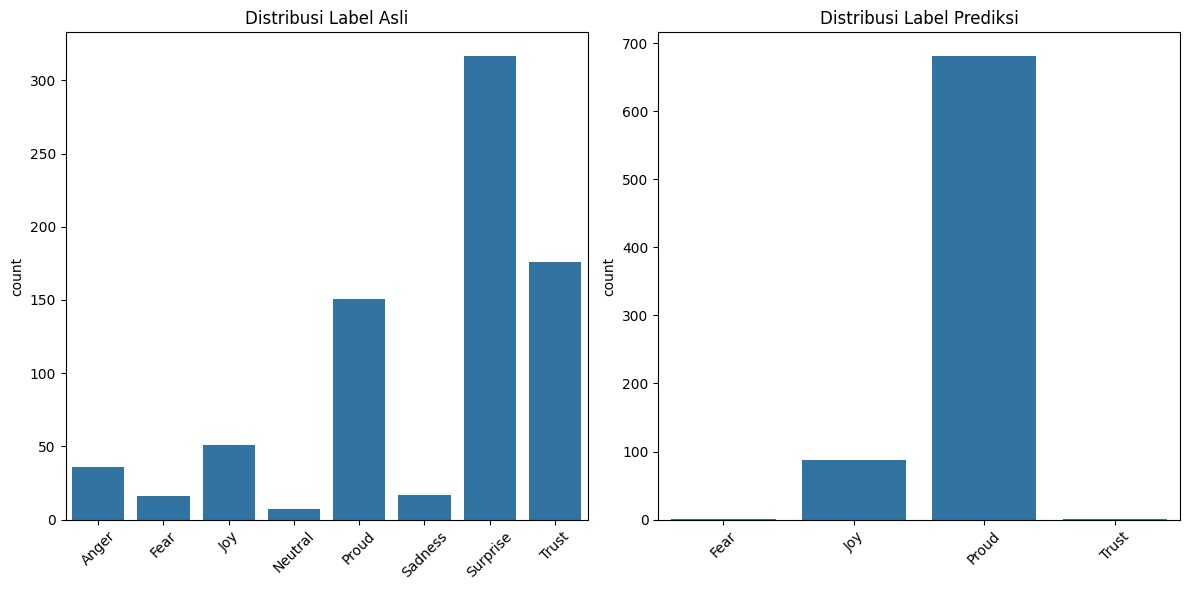


📊 Jumlah tiap label (Asli):
Anger: 36
Fear: 16
Joy: 51
Neutral: 7
Proud: 151
Sadness: 17
Surprise: 317
Trust: 176

📊 Jumlah tiap label (Prediksi):
Fear: 1
Joy: 87
Proud: 682
Trust: 1

✅ Jumlah prediksi benar per label:
Joy: 7 benar dari 51
Proud: 135 benar dari 151


In [157]:
import pandas as pd
from collections import Counter

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.countplot(x=y_true, order=sorted(set(y_true)))
plt.title("Distribusi Label Asli")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.countplot(x=y_pred, order=sorted(set(y_pred)))
plt.title("Distribusi Label Prediksi")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Hitung jumlah label asli & prediksi
true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

# Hitung jumlah prediksi yang benar per label
correct_counts = {}
for t, p in zip(y_true, y_pred):
    if t == p:
        correct_counts[t] = correct_counts.get(t, 0) + 1

correct_counts = pd.Series(correct_counts).sort_index()

print("\n📊 Jumlah tiap label (Asli):")
for lbl, cnt in true_counts.items():
    print(f"{lbl}: {cnt}")

print("\n📊 Jumlah tiap label (Prediksi):")
for lbl, cnt in pred_counts.items():
    print(f"{lbl}: {cnt}")

print("\n✅ Jumlah prediksi benar per label:")
for lbl, cnt in correct_counts.items():
    print(f"{lbl}: {cnt} benar dari {true_counts[lbl]}")



20 Kata yang paling sering muncul:
yang: 3167
ini: 2772
dan: 2428
di: 2262
itu: 1493
bisa: 1408
aku: 1341
ada: 1298
ya: 1268
kita: 1203
juga: 1078
jadi: 1071
banget: 1026
kalau: 1024
dari: 829
nggak: 823
kalian: 797
untuk: 796
pakai: 739
udah: 732
tapi: 729
ke: 725
kayak: 710
karena: 707
dengan: 689
buat: 682
dia: 667
lebih: 642
lagi: 599
atau: 589
gitu: 586
sama: 579
gua: 542
aja: 502
mau: 478
tuh: 469
terus: 466
saya: 461
nya: 455
sampai: 432
adalah: 430
nih: 417
akan: 379
apa: 376
enggak: 375
kamu: 371
gini: 369
banyak: 351
sini: 335
kan: 335
satu: 329
nah: 306
sih: 303
tidak: 294
sekarang: 286
punya: 286
masih: 285
orang: 278
sudah: 274
mobil: 274
gue: 271
dalam: 265
teman: 258
langsung: 249
lu: 249
harus: 246
semua: 246
kali: 243
kulit: 240
tahu: 239
seperti: 224
hari: 222
dulu: 218
benar: 217
3: 211
coba: 210
indonesia: 209
oke: 209
suka: 209
lihat: 208
pertama: 206
2: 205
warna: 205
up: 205
bikin: 203
baru: 201
paling: 196
jangan: 195
pada: 192
dapat: 188
cuma: 187
sangat: 185


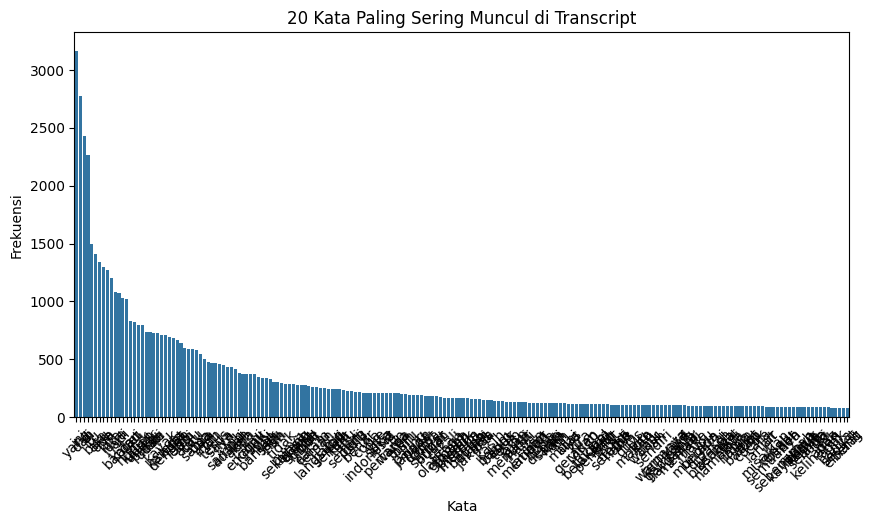

In [119]:
from collections import Counter

# Gabungkan semua transcript jadi satu string
all_text = " ".join(
    [t for t in df_train_merged['transcript'] if isinstance(t, str) and t.strip() != ""]
)

# Pecah jadi list kata
words = all_text.lower().split()

# Hitung frekuensi
word_counts = Counter(words)

# Ambil 20 kata paling sering
top_words = word_counts.most_common(200)

print("\n20 Kata yang paling sering muncul:")
for word, count in top_words:
    print(f"{word}: {count}")

# Visualisasi
plt.figure(figsize=(10,5))
sns.barplot(x=[w for w, _ in top_words], y=[c for _, c in top_words])
plt.xticks(rotation=45)
plt.title("20 Kata Paling Sering Muncul di Transcript")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.show()


In [121]:
from collections import Counter
import re

# --- Hitung frekuensi kata per label ---
word_freq_by_label = {}

for emotion in set(y_true):
    texts = df_train_merged.loc[df_train_merged['emotion_fixed'] == emotion, 'transcript'].dropna()
    all_words = []

    for txt in texts:
        # lower, hanya ambil huruf/angka
        tokens = re.findall(r"\w+", txt.lower())
        all_words.extend(tokens)

    # Counter top 25
    counter = Counter(all_words)
    word_freq_by_label[emotion] = counter.most_common(25)

# --- Print hasil ---
for emotion, top_words in word_freq_by_label.items():
    print(f"\nTop 25 kata untuk label '{emotion}':")
    for word, count in top_words:
        print(f"{word:<15} {count}")



Top 25 kata untuk label 'Fear':
yang            38
itu             29
dan             26
ini             23
ya              21
kita            20
di              19
kalau           19
bisa            17
jadi            15
saya            15
nggak           12
jangan          12
wanita          11
juga            10
dari            10
otak            10
akan            10
kb              10
ada             9
dengan          9
tapi            8
aja             8
saham           8
kan             8

Top 25 kata untuk label 'Trust':
yang            794
dan             607
ini             599
di              503
itu             397
bisa            366
aku             358
kalau           291
kalian          290
ya              280
ada             278
kita            257
juga            245
jadi            235
banget          225
untuk           217
dari            207
ke              198
nggak           186
tapi            182
kayak           179
atau            177
karena          168
deng